```text
Desafio Lighthouse - LH Nautical
Objetivo:
Organizar, tratar e analisar dados de vendas, produtos, clientes e custos,
gerando insights e modelos preditivos.
Autor: Marconi Abou Dehn da Silva Filho
Data: 20/03/2026
```

# 0. Instruções e preparação do ambiente e carregamento dos dados

Este notebook (src/desafio_completo.ipynb) roda em ambiente isolado (toolbox no fedora silverblue) contendo as seguintes ferramentas e bibliotecas instaladas:

pandas numpy matplotlib seaborn sklearn duckdb jupyterlab

Além disso a seguinte estrutura de pastas é esperada:

#### Estrutura do Projeto

```text
.
├── src
│   └── desafio_completo.ipynb - este arquivo
├── data_output
├── data_input
│   ├── custos_importacao.json
│   ├── produtos_raw.csv
│   └── vendas_2023_2024.csv
└── media
    ├── custos_importacao.png
    └── lh_nautical_material_executivo.pdf
```

Você pode rodar instalando as ferramentas listadas e criando a estrutura acima, além de copiar os arquivos corretamente.
Outra opção é clonar o seguinte repositório no github:

git clone https://github.com/Marconiadsf/desafio-indicium-lighthouse



In [1]:
# Importar todas as bibliotecas usadas ao longo do documento:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

import unicodedata
import re
import requests


import warnings
warnings.filterwarnings("ignore")
 

from pathlib import Path
pd.set_option('display.max_columns', None)

In [2]:
# Carregar todos os arquivos que serão usados

# Diretório raiz do projeto (sobe 1 nível a partir de src/)
BASE_DIR = Path().resolve().parent

# Diretório de dados de entrada (brutos)
DATA_INPUT_DIR = BASE_DIR / "data_input"
DATA_OUTPUT_DIR = BASE_DIR / "data_output"

# Nome dos arquivos
file_vendas = "vendas_2023_2024.csv"
file_produtos ="produtos_raw.csv"
# file_clientes ="clientes_crm.json"
file_custos = "custos_importacao.json"

# Caminhos dos arquivos de input
path_input_vendas = DATA_INPUT_DIR / file_vendas
path_input_produtos = DATA_INPUT_DIR / file_produtos
# path_input_clientes = DATA_INPUT_DIR / file_clientes
path_input_custos = DATA_INPUT_DIR / file_custos

# Caminhos dos arquivos de output
path_output_vendas = DATA_OUTPUT_DIR / file_vendas
path_output_produtos = DATA_OUTPUT_DIR / file_produtos
#path_output_clientes = DATA_OUTPUT_DIR / file_clientes
path_output_custos = DATA_OUTPUT_DIR / "custos_importacao.csv" #patch: é solicitado csv como output

# Leitura
df_vendas = pd.read_csv(path_input_vendas)
df_produtos = pd.read_csv(path_input_produtos)
# df_clientes = pd.read_json(path_input_clientes)
df_custos = pd.read_json(path_input_custos)


print("Base dir:", BASE_DIR)
print("Arquivos carregados com sucesso")

Base dir: /var/home/maltil/projects/lighthouse_desafio
Arquivos carregados com sucesso


# 1. Análise exploratória

Antes de qualquer análise, modelagem ou tomada de decisão, é fundamental entender o que existe nos dados. O Sr. Almir quer uma resposta simples: “Posso confiar nesses dados para tomar decisões?”

Farei uma análise exploratória inicial do dataset vendas_2023_2024.csv e responderei perguntas básicas, porém críticas, sobre volume, distribuição e qualidade dos dados.

## 1.1 Visão geral do dataset & Análise de valores numéricos

In [3]:
# Quais colunas?
duckdb.register("vendas", df_vendas)
query = """
SELECT *
FROM vendas
LIMIT 5;
"""
duckdb.query(query).to_df()

,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,15-09-2024
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


In [4]:
query = """
SELECT 
    COUNT(*) AS total_linhas,           -- conta todas as linhas da tabela vendas
                                        
    (                                   
        SELECT COUNT(*)                 
        FROM information_schema.columns 
        WHERE table_name = 'vendas'     
    ) AS total_colunas,                 -- subquery consulta metadados, filtra pela tabela vendas
                                        -- conta quantas colunas existem
    -- agora obtemos as outras informações solicitadas:
    MIN(sale_date) AS data_min,         -- período coberto pelo dataset
    MAX(sale_date) AS data_max,

    MIN(total) AS valor_min,            -- amplitude dos valores de venda
    MAX(total) AS valor_max,
    AVG(total) AS valor_medio

FROM vendas;
"""
duckdb.query(query).to_df()

,total_linhas,total_colunas,data_min,data_max,valor_min,valor_max,valor_medio
0,9895,6,01-01-2023,31-12-2024,294.5,2222973.0,263797.828267


## 1.2 Validação

Valor máximo registrado na coluna total foi 2.222.973,0


## 1.3 Interpretação

A seguir, verificamos a confiabilidade do dataset em três frentes:
qualidade dos dados (nulos e duplicatas), consistência dos valores
numéricos e distribuição estatística para identificação de outliers.

In [5]:
# Checagem de nulos
query = """
SELECT
    COUNT(*) AS total_linhas,
    SUM(CASE WHEN id IS NULL THEN 1 ELSE 0 END) AS null_id,
    SUM(CASE WHEN id_client IS NULL THEN 1 ELSE 0 END) AS null_id_client,
    SUM(CASE WHEN id_product IS NULL THEN 1 ELSE 0 END) AS null_id_product,
    SUM(CASE WHEN qtd IS NULL THEN 1 ELSE 0 END) AS null_qtd,
    SUM(CASE WHEN total IS NULL THEN 1 ELSE 0 END) AS null_total,
    SUM(CASE WHEN sale_date IS NULL THEN 1 ELSE 0 END) AS null_sale_date
FROM vendas;
"""
duckdb.query(query).to_df()

,total_linhas,null_id,null_id_client,null_id_product,null_qtd,null_total,null_sale_date
0,9895,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# Checagem de duplicidade de id
query = """
SELECT 
    COUNT(*) AS total_linhas,
    COUNT(DISTINCT id) AS ids_distintos,
    COUNT(*) - COUNT(DISTINCT id) AS ids_duplicados
FROM vendas;
"""
duckdb.query(query).to_df()

,total_linhas,ids_distintos,ids_duplicados
0,9895,9895,0


In [7]:
# Valores inválidos em total e qtd
query = """
SELECT *
FROM vendas
WHERE total <= 0
   OR qtd <= 0
LIMIT 20;
"""
duckdb.query(query).to_df()

,id,id_client,id_product,qtd,total,sale_date


In [8]:
# Checar o formato de datas
query = """
-- formatos: lista fixa dos três formatos possíveis
-- garante que todos apareçam no resultado mesmo que a contagem seja 0

WITH formatos AS (
    SELECT 'YYYY-MM-DD' AS formato
    UNION ALL
    SELECT 'DD-MM-YYYY'
    UNION ALL
    SELECT 'OUTRO'
),
contagem AS (
    SELECT 
        CASE 
            WHEN sale_date LIKE '____-__-__' THEN 'YYYY-MM-DD'
            WHEN sale_date LIKE '__-__-____' THEN 'DD-MM-YYYY'
            ELSE 'OUTRO'
        END AS formato,
        COUNT(*) AS quantidade
    FROM vendas
    GROUP BY 1
)
SELECT 
    f.formato,
    COALESCE(c.quantidade, 0) AS quantidade
FROM formatos f
LEFT JOIN contagem c
    ON f.formato = c.formato
ORDER BY f.formato;
"""
duckdb.query(query).to_df()

,formato,quantidade
0,DD-MM-YYYY,4982
1,OUTRO,0
2,YYYY-MM-DD,4913


In [9]:
# Calculo de estatísticas relevantes para análise de outliers
query = """
WITH stats AS (
    SELECT 
        MIN(total) AS min,
        PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY total) AS q1,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY total) AS mediana,
        PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY total) AS q3,
        MAX(total) AS max
    FROM vendas
)
SELECT
    min,
    q1,
    mediana,
    q3,
    max,
    (q3 - q1) AS iqr,
    q1 - 1.5 * (q3 - q1) AS limite_inferior,
    q3 + 1.5 * (q3 - q1) AS limite_superior
FROM stats;
"""
duckdb.query(query).to_df()

,min,q1,mediana,q3,max,iqr,limite_inferior,limite_superior
0,294.5,23138.2,82225.0,339094.5,2222973.0,315956.3,-450796.25,813028.95


#### Interpretação:

-> O limite inferior calculado é negativo, enquanto o valor mínimo observado é positivo, o que indica ausência de outliers inferiores.

-> Por outro lado, o valor máximo está significativamente acima do limite superior, sugerindo a presença de outliers superiores relevantes na distribuição da variável total.

-> Não foram encontrados valores nulos.

-> Não é possível afirmar a inexistência de inconsistências nos valores de `total` e `qtd`,uma vez que não foi realizada uma validação cruzada com outras fontes, como preços de produtos. 

-> Ainda assim, não foram identificados valores negativos ou nulos nessas colunas, o que sugere consistência básica dos dados.

-> Por fim, o dataset não está pronto para análises diretas, sendo necessária a padronização do campo `sale_date`, que apresenta múltiplos formatos.

# 2. Produtos

O arquivo `produtos_raw.csv` apresenta inconsistências de nomenclatura nas categorias (variações de grafia e acentuação) e formato heterogêneo na coluna de preços (valores com símbolo de moeda e tipo string). Esta seção padroniza essas inconsistências e remove duplicatas, produzindo `df_produtos_normalizado` — referência única de catálogo usada nos joins das seções seguintes.

## 2.1 Limpeza e padronização

In [10]:
# Visualizar informações básicas dos dados
# df_produtos é o dataframe que aponta para produtos_raw.csv
df_produtos.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   name             157 non-null    str  
 1   price            157 non-null    str  
 2   code             157 non-null    int64
 3   actual_category  157 non-null    str  
dtypes: int64(1), str(3)
memory usage: 5.0 KB


In [11]:
# Visualizar uma amostra para melhor compreensão
df_produtos.head(5)

,name,price,code,actual_category
0,Transponder AIS Maré Magnum,R$ 33122.52,1,ELETRONICOS
1,Transponder Furuno Marlin,R$ 13998.15,2,ELETRONICOS
2,Radar Furuno Pulse Leviathan,R$ 9024.19,3,E L E T R Ô N I C O S
3,Rádio AIS Hydro Tidal Zen,R$ 3381.88,4,Eletrunicos
4,Piloto Automático Furuno Storm,R$ 23669.01,5,Eletronicoz


In [12]:
# Iniciando com uma normalização básica:
# Remoção de acentos e números 
# Remoção de espacos em branco
# Padronização de caixa: baixa/minúscula

df_produtos_normalizado = df_produtos.copy()

# Função de normalização de texto
def normalizar(texto):
    texto = texto.lower().strip()
    texto = ''.join(
        # NFD decompõe caracteres acentuados em letra-base + diacrítico separado
        # category 'Mn' identifica os diacríticos — removê-los deixa só a letra-base
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    texto = re.sub(r'\s+', '', texto)
    texto = re.sub(r'[^a-z0-9]', '', texto)
    return texto

# Aplicar apenas normalização
df_produtos_normalizado['categoria_normalizada'] = df_produtos_normalizado['actual_category'].apply(normalizar)

# Vamos agora verificar como ficaram as categorias
df_produtos_normalizado['categoria_normalizada'].value_counts().sort_index()

categoria_normalizada
ancoragem       27
ancoragen        1
ancoraguem       8
ancorajem        4
ancorajen        2
ancorajm         5
eletronicos     37
eletronicoz      7
eletroniscos     2
eletrunicos      5
encoragem        5
encoragi         1
prop             5
propucao         8
propulcao        8
propulsam        2
propulsao       25
propulssao       5
Name: count, dtype: int64

In [13]:
# Existem vários erros para cada uma das categorias...
# Selecionando visualmente substrings que consigam filtrar todas as variacões:
# ancoragem: ncora se for substring ou encor e ancor para começo de palavra
# eletronicos: eletr
# propulsao: prop 

def mapear_categoria(texto):
    """Mapeia texto normalizado para uma das 3 categorias canônicas."""
    # normalização de categorias
    texto = normalizar(texto)

    # regras explícitas baseadas na análise
    if texto.startswith('eletr'):
        return 'eletronicos'
    elif texto.startswith('prop'):
        return 'propulsao'
    elif texto.startswith('ancor') or texto.startswith('encor'):
        return 'ancoragem'
    else:
        return 'outros'

df_produtos_normalizado['categoria_final'] = df_produtos_normalizado['categoria_normalizada'].apply(mapear_categoria)

df_produtos_normalizado = df_produtos_normalizado[['name','price','code','categoria_final']]

# Renomeando 'categorua_final' para 'actual_category'
df_produtos_normalizado = df_produtos_normalizado.rename(columns={'categoria_final': 'actual_category'})

df_produtos_normalizado['actual_category'].value_counts()


actual_category
propulsao      53
ancoragem      53
eletronicos    51
Name: count, dtype: int64

In [14]:
# Iniciando o tratamento de "price"
# Checando se algum número contém , (poderia haver se estivesse entre " "
df_produtos_normalizado['price'].str.contains(',').sum() 

np.int64(0)

In [15]:
# OK, a coluna de preços está consistente com formato numérico, 
# -> utiliza ponto como separador decimal e sem presença de vírgulas
# Iniciando a conversão:
df_produtos_normalizado['price'] = (
    df_produtos_normalizado['price']
    .str.replace('R$', '', regex=False)
    .str.strip()
    .astype(float)
)

## 2.2 Validação

In [16]:
# Quantos produtos duplicados foram removidos?
df_produtos_normalizado.duplicated().sum()

np.int64(7)

In [17]:
# keep=False marca TODAS as ocorrências do duplicado, não só as repetições
# — permite ver o par completo antes de decidir o que remover
df_produtos_normalizado[df_produtos_normalizado.duplicated(keep=False)]

,name,price,code,actual_category
36,GPS Lowrance Evo Storm Drift,6067.71,37,eletronicos
37,GPS Lowrance Evo Storm Drift,6067.71,37,eletronicos
62,Motor Diesel Yanmar Velocity 37HP,102221.97,62,propulsao
63,Motor Diesel Yanmar Velocity 37HP,102221.97,62,propulsao
64,Motor Diesel Yanmar Velocity 37HP,102221.97,62,propulsao
65,Motor Diesel Yanmar Velocity 37HP,102221.97,62,propulsao
124,Boia de Arqueamento Delta Nexus,4349.86,145,ancoragem
131,Cabo de Nylon Delta Velocity Core Mako,1549.35,127,ancoragem
132,Cabo de Nylon Delta Velocity Core Mako,1549.35,127,ancoragem
150,Boia de Arqueamento Delta Nexus,4349.86,145,ancoragem


In [18]:
df_produtos_normalizado.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             157 non-null    str    
 1   price            157 non-null    float64
 2   code             157 non-null    int64  
 3   actual_category  157 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 5.0 KB


In [19]:
df_produtos_normalizado = df_produtos_normalizado.drop_duplicates().copy()
df_produtos_normalizado.to_csv(path_output_produtos, sep=',', index=False, encoding='utf-8')

# 3. Custos de Importação

O arquivo `custos_importacao.json` armazena o histórico de preços de compra em USD de cada produto em um campo aninhado (`historic_data`), com uma lista de registros por produto. Para viabilizar o AS-OF join da seção 4, é necessário explodir essa estrutura em linhas individuais e converter `start_date` para datetime. O resultado é `df_custos_normalizado` com 1.260 registros.

## 3.1 Normalização dos dados

A seguir, inspecionamos a estrutura bruta do JSON para entender
como os dados estão organizados e definir a estratégia de normalização.

In [20]:
# Observar a estrutura dos dados
df_custos.head()

,product_id,product_name,category,historic_data
0,1,Transponder AIS Maré Magnum,eletrônicos,"[{'start_date': '10/08/2016', 'usd_price': 105..."
1,2,Transponder Furuno Marlin,eletrônicos,"[{'start_date': '23/11/2017', 'usd_price': 432..."
2,3,Radar Furuno Pulse Leviathan,eletrônicos,"[{'start_date': '12/04/2016', 'usd_price': 254..."
3,4,Rádio AIS Hydro Tidal Zen,eletrônicos,"[{'start_date': '04/03/2016', 'usd_price': 909..."
4,5,Piloto Automático Furuno Storm,eletrônicos,"[{'start_date': '10/02/2016', 'usd_price': 600..."


In [21]:
# inspecionar mais detalhadamente a historic_data
df_custos.loc[0, 'historic_data'][:2]

[{'start_date': '10/08/2016', 'usd_price': 10583.63},
 {'start_date': '15/06/2018', 'usd_price': 8778.36}]

In [22]:
# Inspecionar o formado do dataset

df_custos.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     150 non-null    int64 
 1   product_name   150 non-null    str   
 2   category       150 non-null    str   
 3   historic_data  150 non-null    object
dtypes: int64(1), object(1), str(2)
memory usage: 4.8+ KB


A estrutura esperada após a normalização é uma linha por registro de preço histórico, com as seguintes colunas:

| Coluna | Tipo | Descrição |
|---|---|---|
| `product_id` | int | Identificador do produto |
| `product_name` | str | Nome do produto |
| `category` | str | Categoria padronizada |
| `start_date` | datetime | Data de vigência do preço |
| `usd_price` | float | Preço de custo em USD |

In [23]:
# Cada produto tem N registros de preço em historic_data (lista).
# explode() transforma cada elemento da lista em uma linha própria —
# condição necessária para o AS-OF join da seção 4.
df_custos_normalizado = (
    df_custos
    .copy()
    .explode('historic_data', ignore_index=True)
)
# Criamos um dataframe apartir da coluna historic_data e concatenamos 
# de volta no df_custos_normalizado expandindo o dataframe
df_custos_normalizado = pd.concat(
    [
        df_custos_normalizado[['product_id', 'product_name', 'category']].reset_index(drop=True),
        pd.json_normalize(df_custos_normalizado['historic_data']).reset_index(drop=True)
    ],
    axis=1
)


In [24]:
# Analisar o que temos agora
df_custos_normalizado.head(10)

,product_id,product_name,category,start_date,usd_price
0,1,Transponder AIS Maré Magnum,eletrônicos,10/08/2016,10583.63
1,1,Transponder AIS Maré Magnum,eletrônicos,15/06/2018,8778.36
2,1,Transponder AIS Maré Magnum,eletrônicos,25/09/2018,8023.87
3,1,Transponder AIS Maré Magnum,eletrônicos,19/03/2019,8772.78
4,1,Transponder AIS Maré Magnum,eletrônicos,17/01/2020,7918.18
5,1,Transponder AIS Maré Magnum,eletrônicos,17/06/2020,6310.01
6,1,Transponder AIS Maré Magnum,eletrônicos,02/07/2021,6586.70
7,1,Transponder AIS Maré Magnum,eletrônicos,16/05/2022,6538.20
8,1,Transponder AIS Maré Magnum,eletrônicos,28/02/2023,6360.91
9,1,Transponder AIS Maré Magnum,eletrônicos,17/10/2023,6574.80


In [25]:
# Inspeções na coluna start_date
mask_formato_valido = df_custos_normalizado['start_date'].str.match(r'^\d{2}/\d{2}/\d{4}$')
print(f"Mask info:\n{mask_formato_valido.value_counts()} \nEntradas no df_custos_normalizado: {len(df_custos_normalizado)}")

# Checagem extra: Será que misturaram formatos br/us? 
print(f"Valor máximo em 'mês': {df_custos_normalizado['start_date'].str[3:5].astype(int).max()}")
# Se >12 pode ser que tenham digitado dia no lugar de mês..pode ocorrer se digitaram dias menores que 12 
# mas isso nao é detectável por que em dia pode ser qualquer valor de 1 a 31...
# Só daria pra detectar outros erros em edge cases: dias >31 ou datas fora do range permitido. 
# Qual o range?
# Checagem se os numeros em "dia" são válidos:
print(f"Valor máximo em 'dia': {df_custos_normalizado['start_date'].str[:2].astype(int).max()}")


Mask info:
start_date
True    1260
Name: count, dtype: int64 
Entradas no df_custos_normalizado: 1260
Valor máximo em 'mês': 12
Valor máximo em 'dia': 31


In [26]:
# Converter a start_date
df_custos_normalizado['start_date'] = pd.to_datetime(
    df_custos_normalizado['start_date'],
    format='%d/%m/%Y'
)

In [27]:
#Verificando tipos após expansão:
df_custos_normalizado.info()

<class 'pandas.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   product_id    1260 non-null   int64         
 1   product_name  1260 non-null   str           
 2   category      1260 non-null   str           
 3   start_date    1260 non-null   datetime64[us]
 4   usd_price     1260 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 49.3 KB


In [28]:
# Tudo certo! Gerar a saída:
df_custos_normalizado.to_csv(path_output_custos, sep=',', index=False, encoding='utf-8')

## 3.2 Validação

In [29]:
# Quantas entradas de importação o CSV recebeu ao todo após a normalização?
# Conforme visto acima: 1260. Confirmando:
df_custos_normalizado.shape[0]

1260

# 4. Dados Públicos

O Sr. Almir suspeita que produtos foram vendidos abaixo do custo.
O desafio: vendas estão em BRL, custos em USD, e o câmbio varia diariamente.
Cruzamos as três fontes — vendas, custos históricos e PTAX do BCB —
para identificar onde houve prejuízo real.

In [30]:
# Precisamos da cotação do dólar.
# Abordagem: baixar uma cotação do Banco Central que compreenda o intervalo
# no arquivo de vendas.
# Além disso é solicitado que a agregação desses valores seja feito no SQL
# Nota: sale_date ainda está como string neste ponto — o parse de datas
# é feito dentro da query SQL via CASE/STRPTIME (ver CTE vendas_tratadas).

# -----------------------------------------------------------------------------
# Banco Central informa que, desde 1º de julho de 2011, a PTAX passou a ser a 
# média aritmética de quatro consultas diárias aos dealers, e que o boletim de 
# fechamento PTAX é a média aritmética dos boletins do dia.
#------------------------------------------------------------------------------


# DATAS PARA A URL (O Banco Central EXIGE Mês-Dia-Ano)
# Datas da tabela venda (Q1) : min: 01-01-2023 	max: 31-12-2024
# Mudei para 20/12/2022 para garantir que o dia 01/01/2023 tenha cotação anterior para puxar (ffill)
data_ini_url = '12-20-2022' 
data_fim_url = '12-31-2024'


url = (
    "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/"
    f"CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)"
    f"?@dataInicial='{data_ini_url}'"
    f"&@dataFinalCotacao='{data_fim_url}'"
    "&$top=10000"
    "&$format=json"
)

# Ler JSON cru da API
resp = requests.get(url, timeout=30)
resp.raise_for_status()
payload = resp.json()

type(payload), payload.keys()

(dict, dict_keys(['@odata.context', 'value']))

In [31]:
# payload['value'] contém a lista de cotações — inspecionar os dois primeiros registros
# para confirmar os campos disponíveis antes de montar o dataframe.
payload['value'][:2]

[{'cotacaoCompra': 5.2421,
  'cotacaoVenda': 5.2427,
  'dataHoraCotacao': '2022-12-20 13:07:21.434'},
 {'cotacaoCompra': 5.2025,
  'cotacaoVenda': 5.2031,
  'dataHoraCotacao': '2022-12-21 13:06:24.155'}]

In [32]:
# Extrair lista de registros transformando em dataframe
df_ptax = pd.DataFrame(payload['value'])
df_ptax.info()



<class 'pandas.DataFrame'>
RangeIndex: 511 entries, 0 to 510
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cotacaoCompra    511 non-null    float64
 1   cotacaoVenda     511 non-null    float64
 2   dataHoraCotacao  511 non-null    str    
dtypes: float64(2), str(1)
memory usage: 12.1 KB


In [33]:
# Manter só o necessário - data e cotacao de venda
df_ptax = df_ptax[['dataHoraCotacao', 'cotacaoVenda']].copy() #conforme premissas obrigatorias

# Converter tipos de data do bc
df_ptax['dataHoraCotacao'] = pd.to_datetime(df_ptax['dataHoraCotacao'])
df_ptax['data'] = df_ptax['dataHoraCotacao'].dt.normalize()
df_ptax = df_ptax[['data', 'cotacaoVenda']].copy()
df_ptax = df_ptax.sort_values('data').reset_index(drop=True)
df_ptax.head(10)


,data,cotacaoVenda
0,2022-12-20,5.2427
1,2022-12-21,5.2031
2,2022-12-22,5.1871
3,2022-12-23,5.1445
4,2022-12-26,5.1872
5,2022-12-27,5.2832
6,2022-12-28,5.2736
7,2022-12-29,5.2177
8,2022-12-30,5.2177
9,2023-01-02,5.3436


In [34]:
# Para tratar fins de semana e feriados:
# Criar calendário:
df_calendario = pd.DataFrame({
    'data': pd.date_range(start='2022-12-20', end='2024-12-31', freq='D')
})

# Cruzar o calendário com a PTAX diária
# Dias sem cotação (fins de semana/feriados) ficarão com NaN
df_calendario_ptax = df_calendario.merge(
    df_ptax,
    on='data',
    how='left'
)
# Daí preenchemos com a ultima cotacao usando ffill
df_calendario_ptax['cotacaoVenda'] = df_calendario_ptax['cotacaoVenda'].ffill()

print(df_calendario_ptax.head(10))
print(f"Sobrou algum valor nulo? 0 para não:{df_calendario_ptax['cotacaoVenda'].isna().sum()}")

        data  cotacaoVenda
0 2022-12-20        5.2427
1 2022-12-21        5.2031
2 2022-12-22        5.1871
3 2022-12-23        5.1445
4 2022-12-24        5.1445
5 2022-12-25        5.1445
6 2022-12-26        5.1872
7 2022-12-27        5.2832
8 2022-12-28        5.2736
9 2022-12-29        5.2177
Sobrou algum valor nulo? 0 para não:0


## 4.1 Receita e Prejuízo

Para calcular o prejuízo real por transação, é necessário converter o custo
unitário em USD para BRL usando o câmbio do dia da venda (PTAX BCB).
A lógica central é:

    custo_total_brl = custo_usd_vigente × cotacao_venda_do_dia × quantidade

Uma transação tem prejuízo quando `custo_total_brl > total` (receita da venda).
O AS-OF join garante que o custo USD aplicado seja o vigente na data da venda,
respeitando o histórico de preços do catálogo.

In [35]:
# Registrando novos dataframes no duckdb
duckdb.register("custos", df_custos_normalizado)      # veio do JSON normalizado
duckdb.register("cambio", df_calendario_ptax)         # veio da PTAX + calendário + ffill

In [36]:
query = """
-- Q4.1 - Cálculo do custo em BRL por transação e agregação por produto

WITH vendas_tratadas AS (
    SELECT
        id,
        id_client,
        id_product,
        qtd,
        total,

        -- Padroniza a data da venda, que pode vir em dois formatos
        CASE
            WHEN sale_date LIKE '____-__-__' THEN CAST(sale_date AS DATE)
            WHEN sale_date LIKE '__-__-____' THEN STRPTIME(sale_date, '%d-%m-%Y')::DATE
            ELSE NULL
        END AS sale_date_dt
    FROM vendas
),

custos_vigentes AS (
    SELECT
        v.id,
        v.id_client,
        v.id_product,
        v.qtd,
        v.total,
        v.sale_date_dt,
        c.start_date,
        c.usd_price,

        -- Para cada venda, escolhe o custo mais recente
        -- cuja vigência começou até a data da venda
        ROW_NUMBER() OVER (
            PARTITION BY v.id
            ORDER BY c.start_date DESC
        ) AS rn
    FROM vendas_tratadas v
    LEFT JOIN custos c
        ON v.id_product = c.product_id
       AND c.start_date <= v.sale_date_dt
),

transacoes_modeladas AS (
    SELECT
        cv.id,
        cv.id_product,
        cv.qtd,
        cv.total,
        cv.sale_date_dt,
        cv.usd_price,

        -- Câmbio do dia da venda
        cb.cotacaoVenda AS taxa_cambio_data,

        -- Custo unitário em BRL
        cv.usd_price * cb.cotacaoVenda AS custo_unitario_brl,

        -- Custo total da transação em BRL
        cv.usd_price * cb.cotacaoVenda * cv.qtd AS custo_total_brl,

        -- Prejuízo da transação:
        -- apenas quando o custo total supera a receita da transação
        CASE
            WHEN (cv.usd_price * cb.cotacaoVenda * cv.qtd) > cv.total
            THEN (cv.usd_price * cb.cotacaoVenda * cv.qtd) - cv.total
            ELSE 0
        END AS prejuizo_transacao
    FROM custos_vigentes cv
    LEFT JOIN cambio cb
        ON cv.sale_date_dt = cb.data
    WHERE cv.rn = 1
)

SELECT
    id_product,

    -- Receita total do produto: todas as vendas
    SUM(total) AS receita_total,

    -- Prejuízo total: soma apenas das transações com perda
    SUM(prejuizo_transacao) AS prejuizo_total,

    -- Percentual de perda sobre a receita total
    SUM(prejuizo_transacao) / NULLIF(SUM(total), 0) AS percentual_perda

FROM transacoes_modeladas
GROUP BY id_product
ORDER BY percentual_perda DESC;
"""

duckdb.query(query).to_df()

,id_product,receita_total,prejuizo_total,percentual_perda
0,72,63057815.65,3.982104e+07,0.631500
1,83,44377440.00,1.861429e+07,0.419454
2,109,328320.15,1.020613e+05,0.310859
3,102,335379.20,9.649971e+04,0.287733
4,136,1049801.00,2.527528e+05,0.240763
...,...,...,...,...
145,113,2210235.65,2.654370e+04,0.012009
146,24,9471755.80,7.234989e+04,0.007638
147,13,3774383.00,2.681163e+04,0.007104
148,126,1388455.25,7.634687e+03,0.005499


### 4.1.1 Visualização — Prejuízo por Produto

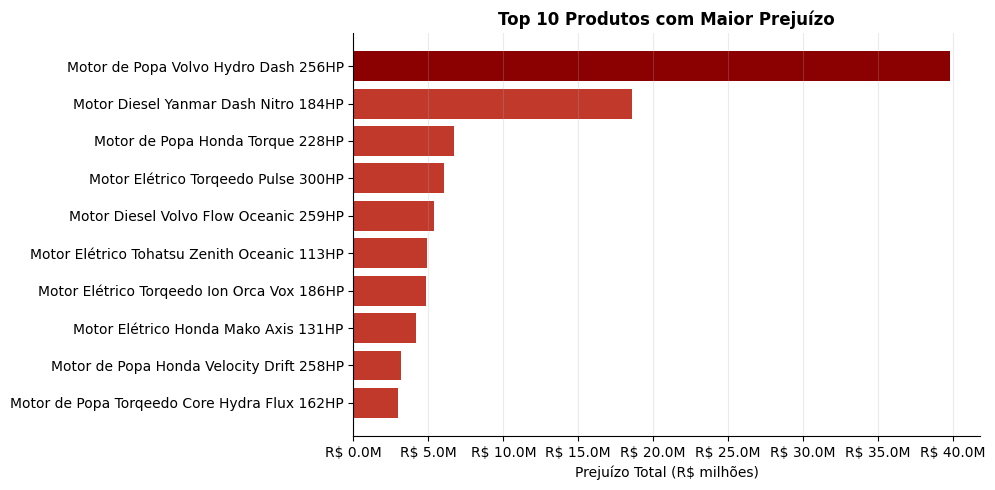

In [37]:
# Gráfico de prejuízo por produto — salvo em media/

query = """
-- Base para gráfico: prejuízo total por produto
WITH vendas_tratadas AS (
    SELECT
        id,
        id_client,
        id_product,
        qtd,
        total,
        CASE
            WHEN sale_date LIKE '____-__-__' THEN CAST(sale_date AS DATE)
            WHEN sale_date LIKE '__-__-____' THEN STRPTIME(sale_date, '%d-%m-%Y')::DATE
            ELSE NULL
        END AS sale_date_dt
    FROM vendas
),

custos_vigentes AS (
    SELECT
        v.id,
        v.id_client,
        v.id_product,
        v.qtd,
        v.total,
        v.sale_date_dt,
        c.product_name,
        c.start_date,
        c.usd_price,
        ROW_NUMBER() OVER (
            PARTITION BY v.id
            ORDER BY c.start_date DESC
        ) AS rn
    FROM vendas_tratadas v
    LEFT JOIN custos c
        ON v.id_product = c.product_id
       AND c.start_date <= v.sale_date_dt
),

transacoes_modeladas AS (
    SELECT
        cv.id,
        cv.id_product,
        cv.product_name,
        cv.qtd,
        cv.total,
        cv.sale_date_dt,
        cv.usd_price,
        cb.cotacaoVenda AS taxa_cambio_data,
        cv.usd_price * cb.cotacaoVenda * cv.qtd AS custo_total_brl,
        CASE
            WHEN (cv.usd_price * cb.cotacaoVenda * cv.qtd) > cv.total
            THEN (cv.usd_price * cb.cotacaoVenda * cv.qtd) - cv.total
            ELSE 0
        END AS prejuizo_transacao
    FROM custos_vigentes cv
    LEFT JOIN cambio cb
        ON cv.sale_date_dt = cb.data
    WHERE cv.rn = 1
)

SELECT
    id_product,
    product_name,
    SUM(prejuizo_transacao) AS prejuizo_total
FROM transacoes_modeladas
GROUP BY id_product, product_name
HAVING SUM(prejuizo_transacao) > 0
ORDER BY prejuizo_total DESC;
"""
df_prejuizo = duckdb.query(query).to_df()

# Nota: Será plotado apenas o top 10 por que 150 produtos fica ilegível....

df_plot = df_prejuizo.sort_values('prejuizo_total', ascending=False).head(10)
cores = ['#8B0000' if i == 0 else '#C0392B' for i in range(len(df_plot))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df_plot['product_name'], df_plot['prejuizo_total'], color=cores)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
ax.set_xlabel('Prejuízo Total (R$ milhões)')
ax.set_title('Top 10 Produtos com Maior Prejuízo', fontweight='bold')
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(BASE_DIR / 'media/top10_prejuizo_vermelho.png', dpi=150, bbox_inches='tight')

## 4.2 Validação

#### id_produto que apresentou a maior porcentagem de perda financeira relativa (maior % de prejuízo sobre sua receita) no período analisado: 
> 72 com 63,15% de prejuízo.

## 4.3 Desenvolvimento e suposições

#### 1. Qual data de câmbio você utilizou?
Foi utilizada a cotação de venda do dólar (PTAX) do Banco Central correspondente à data da venda (sale_date) 
de cada transação.
Como não há cotação para fins de semana e feriados, foi aplicado um forward fill (ffill), utilizando a 
última cotação disponível anterior para esses dias.

#### 2.Como definiu o prejuízo?
O prejuízo foi definido como a diferença entre o custo total da transação em BRL e o valor da venda, 
apenas quando o custo supera a receita:
    prejuízo = max(custo_total_brl - total_venda, 0)

Onde:

>    custo_total_brl = custo_usd * taxa_cambio_data * quantidade

Assim, apenas transações com perda efetiva contribuem para o prejuízo total.

#### 3. Alguma suposição relevante?

Suposições realizadas:
Foi assumido que o custo aplicável a cada venda é o custo mais recente vigente até a data da venda 
(start_date <= sale_date), uma vez que o dataset não explicita diretamente qual custo deve ser utilizado 
por transação.
Foi assumido que a taxa PTAX obtida representa adequadamente o câmbio efetivo das transações, embora na 
prática operações possam ocorrer com spreads ou taxas diferentes.
Para datas sem cotação (fins de semana e feriados), foi assumido que a melhor aproximação é utilizar a 
última cotação disponível anterior (ffill).
Foi assumido que os dados de custo em USD e os dados de vendas estão corretos e comparáveis, não sendo 
possível validar inconsistências externas (ex: erro de cadastro de preço ou unidade de custo).

Observação: 

-> Alguns dos valores de prejuízo observados são significativamente superiores ao que seria esperado apenas 
por variação cambial, indicando que o câmbio, isoladamente, não explica o prejuízo observado.

-> 62,4% de todas as transações (6.172 de 9.895) resultaram em prejuízo, e todos os 150 produtos tiveram ao menos uma venda abaixo do custo — o que sugere que o problema não é pontual ou operacional, mas sistemático.


# 5. Análise de clientes

A diretoria quer identificar os clientes fiéis: alto ticket médio e diversidade de categorias. Calculamos ticket médio e diversidade por cliente, filtramos os top 10 e identificamos a categoria mais consumida por esse grupo.


## 5.1 Limpeza de dados


In [38]:
# Já realizei a limpeza anteriormente (Q2) , conforme podemos observar:
df_produtos_normalizado.actual_category.value_counts()


actual_category
eletronicos    50
propulsao      50
ancoragem      50
Name: count, dtype: int64

In [39]:
# Código em SQL calculando:
# 1. O Ticket Médio e a Diversidade de categorias por cliente.
# 2. A identificação e filtro dos 10 clientes "Fiéis" (maior Ticket Médio entre aqueles com diversidade >= 3 categorias).
# 3. A categoria mais vendida (em quantidade total de itens) considerando apenas o histórico desses 10 clientes.

# Primeiro registro a tabela de produtos que normalizei na q2:
duckdb.register("produtos", df_produtos_normalizado)  

# Agora posso gerar a query e realizar a consulta:

query = """
-- Objetivo:
-- 1) Calcular o ticket médio e a diversidade de categorias por cliente
-- 2) Filtrar os 10 clientes "fiéis":
--      - maior ticket médio
--      - considerando apenas clientes com diversidade >= 3 categorias
--      - desempate por id_client crescente
-- 3) Descobrir, para esses 10 clientes, qual categoria teve a maior quantidade total de itens comprados

WITH vendas_com_categoria AS (
    SELECT
        v.id,                 -- id da transação
        v.id_client,          -- cliente
        v.id_product,         -- produto comprado
        v.qtd,                -- quantidade de itens na transação
        v.total,              -- valor total da transação em BRL
        p.actual_category     -- categoria já limpa vinda da tabela de produtos
    FROM vendas v
    LEFT JOIN produtos p
        ON v.id_product = p.code
),

metricas_cliente AS (
    SELECT
        id_client,

        -- Faturamento total do cliente:
        -- soma de todas as compras realizadas
        SUM(total) AS faturamento_total,

        -- Frequência:
        -- quantidade total de transações realizadas pelo cliente
        COUNT(id) AS frequencia,

        -- Ticket médio:
        -- faturamento total dividido pela frequência
        SUM(total) / COUNT(id) AS ticket_medio,

        -- Diversidade de categorias:
        -- quantidade de categorias distintas compradas pelo cliente
        COUNT(DISTINCT actual_category) AS diversidade_categorias
    FROM vendas_com_categoria
    GROUP BY id_client
),

clientes_fieis AS (
    SELECT
        id_client,
        faturamento_total,
        frequencia,
        ticket_medio,
        diversidade_categorias
    FROM metricas_cliente

    -- Filtro de elite:
    -- só entram clientes com 3 ou mais categorias distintas
    WHERE diversidade_categorias >= 3

    -- Ranking:
    -- maior ticket médio primeiro
    -- em caso de empate, menor id_client primeiro
    ORDER BY ticket_medio DESC, id_client ASC

    -- Mantém apenas os 10 melhores
    LIMIT 10
),

consumo_top10 AS (
    SELECT
        vcc.actual_category,
        SUM(vcc.qtd) AS total_itens
    FROM vendas_com_categoria vcc
    INNER JOIN clientes_fieis cf
        ON vcc.id_client = cf.id_client

    -- Soma a quantidade comprada por categoria,
    -- considerando apenas o histórico dos 10 clientes fiéis
    GROUP BY vcc.actual_category
)

SELECT
    actual_category AS categoria_mais_vendida,
    total_itens
FROM consumo_top10

-- Categoria com maior quantidade total de itens
ORDER BY total_itens DESC

-- Se houver empate, ordena alfabeticamente para deixar determinístico
LIMIT 1;
"""
duckdb.query(query).to_df()


,categoria_mais_vendida,total_itens
0,propulsao,6030.0


## 5.2 Validação
Considerando apenas as compras realizadas pelos Top 10 Clientes selecionados (Critério: Maior Ticket Médio com 3+ categorias): 
a categoria de produtos mais vendida para eles em quantidade total de itens foi a categoria propulsao.

## 5.3 Justificativa

#### Limpeza das categorias:
As categorias já haviam sido tratadas previamente no arquivo de produtos,com padronização das variações de grafia para uma categoria única por grupo. Na Q5, utilizei diretamente essa versão já normalizada da tabela de produtos, evitando duplicidade semântica entre categorias como “Ancorajen”, “Encoragem” e “Ancoragem”

#### Lógica de filtragem (diversidade mínima)
Primeiro, associei cada venda à categoria do produto por meio do id_product. Em seguida, calculei a diversidade de categorias por clientecom COUNT(DISTINCT actual_category). Depois apliquei o filtro diversidade_categorias >= 3, conforme a regra do enunciado. Entre esses clientes, ordenei pelo maior ticket_medio e, em caso de empate, por id_client em ordem crescente, selecionando os 10 primeiros.

#### Contagem do top10:
Criei uma CTE específica contendo somente os 10 clientes fiéis já filtrados. Depois, fiz um INNER JOIN entre essa CTE e a tabela de vendas com categoria, garantindo que a soma de qtd por categoria fosse calculada exclusivamente sobre o histórico desses 10 clientes, sem incluir os demais.

# 6. Dimensão de calendário

O Sr. Almir quer saber: "Qual é o dia da semana (Segunda, Terça...) que temos a pior média de vendas?" para decidir se vale a pena fechar a loja nesses dias.

Um estagiário fez um GROUP BY dia_semana direto na tabela de vendas e disse que a Terça-feira era ótima, com média de R$5.000,00. 

Porém em muitas terças-feiras a loja abriu mas vendeu zero. Como esses dias não existem na tabela de vendas (vendas_2023_2024.csv), eles foram ignorados no cálculo da média, inflando o resultado. Precisamos corrigir isso utilizando um calendário de datas (dimensão de datas)




## 6.1 Dimensão de datas

In [40]:
# Dimensão de calendário: cobre todos os dias do período,
# incluindo dias sem venda (que receberão total = 0 via LEFT JOIN)
# 
query = """
-- Q6.1
-- Objetivo:
-- 1) Padronizar a data de venda
-- 2) Descobrir a menor e a maior data do período
-- 3) Criar um calendário diário completo entre essas datas
-- 4) Somar as vendas por dia
-- 5) Fazer LEFT JOIN com o calendário para incluir dias sem venda
-- 6) Substituir dias sem venda por 0
-- 7) Calcular a média de vendas por dia da semana, em português

WITH vendas_tratadas AS (
    SELECT
        -- Padroniza a data da venda, que pode vir em dois formatos
        CASE
            WHEN sale_date LIKE '____-__-__' THEN CAST(sale_date AS DATE)
            WHEN sale_date LIKE '__-__-____' THEN STRPTIME(sale_date, '%d-%m-%Y')::DATE
            ELSE NULL
        END AS data_venda,
        total
    FROM vendas
),

periodo AS (
    SELECT
        MIN(data_venda) AS data_min,
        MAX(data_venda) AS data_max
    FROM vendas_tratadas
),

calendario AS (
    SELECT
        gs.data AS data
    FROM periodo p,
    
    -- generate_series expande o intervalo [data_min, data_max] em linhas diárias:
    LATERAL generate_series(p.data_min, p.data_max, INTERVAL 1 DAY) AS gs(data)
),

vendas_diarias AS (
    SELECT
        data_venda,
        SUM(total) AS valor_venda_dia
    FROM vendas_tratadas
    GROUP BY data_venda
),

calendario_com_vendas AS (
    SELECT
        c.data,

        -- Nome do dia da semana em português
        CASE EXTRACT(DOW FROM c.data)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda-feira'
            WHEN 2 THEN 'Terça-feira'
            WHEN 3 THEN 'Quarta-feira'
            WHEN 4 THEN 'Quinta-feira'
            WHEN 5 THEN 'Sexta-feira'
            WHEN 6 THEN 'Sábado'
        END AS dia_semana,

        -- Dias sem venda recebem zero
        COALESCE(vd.valor_venda_dia, 0) AS valor_venda_dia
    FROM calendario c
    LEFT JOIN vendas_diarias vd
        ON c.data = vd.data_venda
)

SELECT
    dia_semana,
    AVG(valor_venda_dia) AS media_vendas
FROM calendario_com_vendas
GROUP BY dia_semana

-- Ordenação lógica dos dias da semana
ORDER BY
    CASE dia_semana
        WHEN 'Domingo' THEN 1
        WHEN 'Segunda-feira' THEN 2
        WHEN 'Terça-feira' THEN 3
        WHEN 'Quarta-feira' THEN 4
        WHEN 'Quinta-feira' THEN 5
        WHEN 'Sexta-feira' THEN 6
        WHEN 'Sábado' THEN 7
    END;
"""
duckdb.query(query).to_df()

,dia_semana,media_vendas
0,Domingo,3.319504e+06
1,Segunda-feira,3.465138e+06
2,Terça-feira,3.627046e+06
3,Quarta-feira,3.535266e+06
4,Quinta-feira,3.626232e+06
5,Sexta-feira,3.715003e+06
6,Sábado,3.710541e+06


## 6.2 Validação

#### Validação: Após considerar os dias zerados no cálculo: Qual é o Dia da Semana (ex: Domingo, Segunda...) que apresenta a menor média de vendas histórica, e qual é o valor dessa média arredondada para 2 casas decimais?

> Domingo — média de R$ 3.319.503,57

## 6.3 Justificativa 

#### 1. Por que é necessário utilizar uma tabela de datas (calendário) em vez de agrupar diretamente a tabela de vendas? 
A tabela de vendas só contém dias em que houve ao menos uma transação. Dias sem venda simplesmente não existem nela. Ao fazer GROUP BY dia_semana diretamente, o denominador do AVG conta apenas os dias com venda — inflando a média. O calendário garante que todos os dias do período existam como linhas, com valor 0 quando não há venda, tornando o denominador correto.

#### 2. O que aconteceria com a média de vendas se um dia da semana tivesse muitos dias sem nenhuma venda registrada?
A média dele fica inflada — parece melhor do que é. Se Segunda tivesse sistematicamente mais dias sem venda que os outros dias, ela subiria artificialmente no ranking sem o calendário. O Sr. Almir poderia concluir que Segunda é um bom dia quando na verdade é o pior.

# 7. Previsão de demanda

O estoque de produtos sazonais gerou prejuízo por falta de previsão.
Gabriel quer um modelo preditivo para ajustar compras com fornecedores.
Aplicamos um baseline de Média Móvel de 7 dias ao produto
Motor de Popa Yamaha Evo Dash 155HP, avaliando com MAE no mês de janeiro/2024.

## 7.1 Construção do modelo

**Abordagem:** Baseline de Média Móvel de 7 dias (MM7).

Para cada dia D do período de teste (janeiro/2024), a previsão é a média
das vendas dos 7 dias imediatamente anteriores a D. Nenhum parâmetro é
aprendido — a fórmula é fixa e definida antes de ver qualquer dado de teste,
garantindo ausência de data leakage.

**Período de treino:** dados até 31/12/2023  
**Período de teste:** 01/01/2024 a 31/01/2024  
**Produto analisado:** Motor de Popa Yamaha Evo Dash 155HP (code=54)


  ETAPA 1 — INFORMAÇÕES DOS DATAFRAMES

→ vendas_2023_2024.csv  : 9,895 linhas, 6 colunas
→ produtos_raw.csv      : 150 linhas, 4 colunas

  ETAPA 2 — NORMALIZAÇÃO DAS DATAS

→ Datas irreparáveis após os 2 parses: 0
✓ Datas normalizadas. Período total: 2023-01-01 → 2024-12-31

  ETAPA 3 — IDENTIFICAÇÃO DO PRODUTO-ALVO

✓ Produto localizado:
  Nome      : Motor de Popa Yamaha Evo Dash 155HP
  Código    : 54
  Categoria : propulsao
  Preço     : R$ 121,534.82

  ETAPA 4 — CONSTRUÇÃO DA SÉRIE TEMPORAL DIÁRIA

→ Transações do produto-alvo no dataset: 62
→ Dias com venda > 0  : 58
→ Dias com venda = 0  : 630
→ Média diária (geral): 0.8081 unidades
→ Máximo diário       : 23 unidades

  ETAPA 5 — SPLIT TREINO / TESTE

→ Treino : 2023-01-10 → 2023-12-31 (356 dias)
→ Teste  : 2024-01-01 → 2024-01-31 (31 dias)

  ETAPA 6 — MODELO BASELINE (Média Móvel 7 dias)

  Data           Real   Previsto   Erro Abs
  --------------------------------------------
  01/01/2024        0     0.0000     0.0000


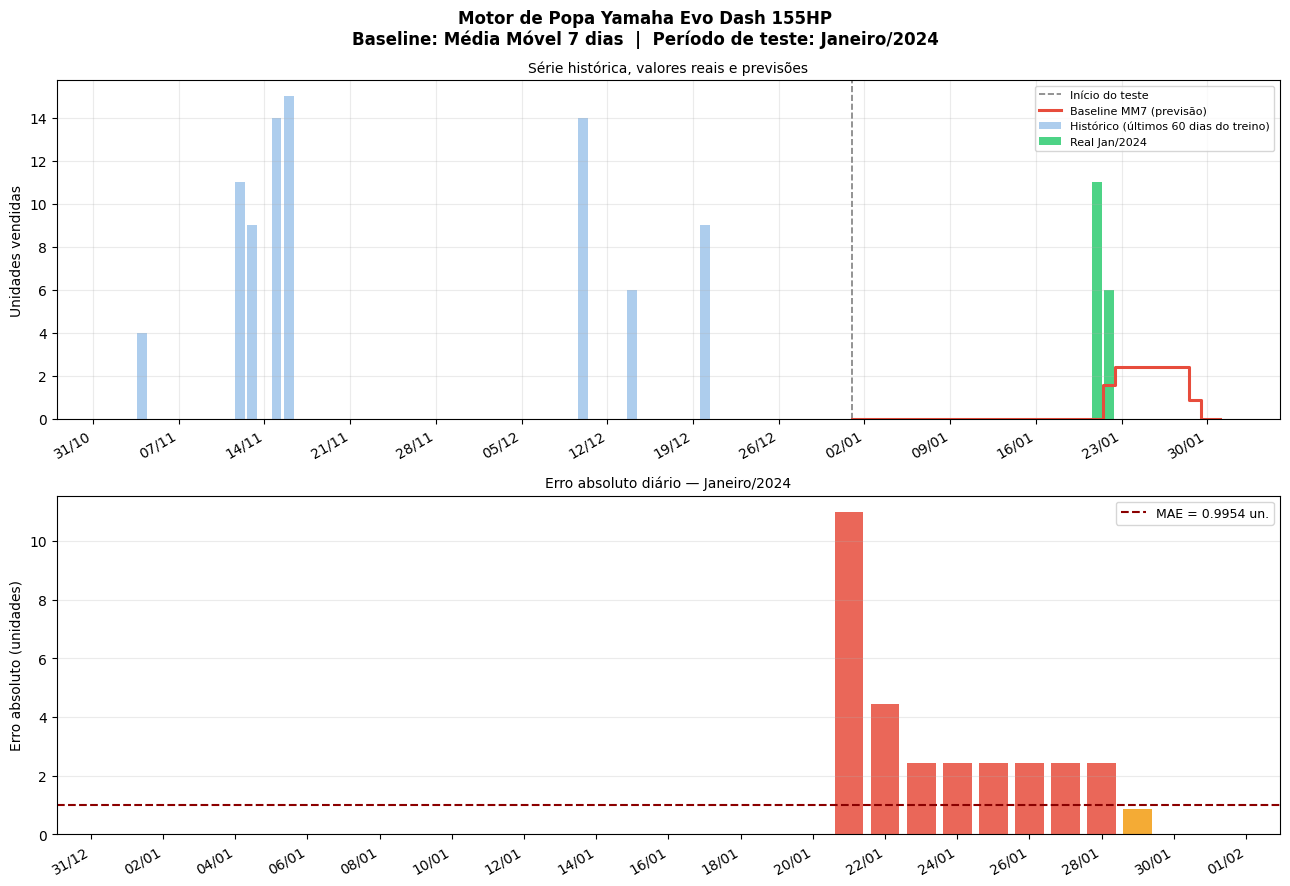


✓ Gráfico salvo como 'previsao_yamaha_resultado.png'


In [41]:
# =============================================================================
# PREVISÃO DE VENDAS — Motor de Popa Yamaha Evo Dash 155HP
# Método: Baseline com Média Móvel de 7 dias
# =============================================================================
 

# =============================================================================
# BLOCO 1 — LEITURA DOS ARQUIVOS
# =============================================================================
# Já foram carregados anteriormente.
print("\n" + "=" * 65)
print("  ETAPA 1 — INFORMAÇÕES DOS DATAFRAMES")
print("=" * 65) 
print(f"\n→ vendas_2023_2024.csv  : {df_vendas.shape[0]:,} linhas, "
      f"{df_vendas.shape[1]} colunas")
print(f"→ produtos_raw.csv      : {df_produtos_normalizado.shape[0]:,} linhas, "
      f"{df_produtos_normalizado.shape[1]} colunas")
 
 
# =============================================================================
# BLOCO 2 — LIMPEZA DAS DATAS
# =============================================================================
# ✔ MUDANÇA v2: descoberto na inspeção que exatamente METADE do dataset usa
#   cada formato: 4.982 linhas em DD-MM-YYYY e 4.913 linhas em YYYY-MM-DD.
 
print("\n" + "=" * 65)
print("  ETAPA 2 — NORMALIZAÇÃO DAS DATAS")
print("=" * 65)
 
# Passe 1: formato ISO (YYYY-MM-DD) — cobre ~50% das linhas
datas = pd.to_datetime(df_vendas["sale_date"], errors="coerce", format="%Y-%m-%d")
 
# Passe 2: formato invertido (DD-MM-YYYY) — cobre os NaT do passe 1
mascara_nat = datas.isna()
datas[mascara_nat] = pd.to_datetime(
    df_vendas.loc[mascara_nat, "sale_date"],
    errors="coerce",
    format="%d-%m-%Y"
)
 
restantes = datas.isna().sum()
print(f"\n→ Datas irreparáveis após os 2 parses: {restantes}")
# Resultado real: 0 — todos os registros foram convertidos com sucesso
 
df_vendas["sale_date"] = datas
 
# Remover linhas com data inválida (precaução)
if restantes > 0:
    df_vendas = df_vendas.dropna(subset=["sale_date"])
    print(f"  ⚠ {restantes} registros removidos por data inválida.")
 
print(f"✓ Datas normalizadas. Período total: "
      f"{df_vendas['sale_date'].min().date()} → "
      f"{df_vendas['sale_date'].max().date()}")
 
 
# =============================================================================
# BLOCO 3 — IDENTIFICAÇÃO DO PRODUTO-ALVO
# =============================================================================
# ✔ MUDANÇA v2: a coluna de categorias no arquivo real chama-se
#   "actual_category" (não "category"). O produto encontrado tem código 54
#   e pertence à categoria "propulsao".
 
print("\n" + "=" * 65)
print("  ETAPA 3 — IDENTIFICAÇÃO DO PRODUTO-ALVO")
print("=" * 65)
 
PRODUTO_ALVO = "Motor de Popa Yamaha Evo Dash 155HP"
 
linha_produto = df_produtos_normalizado[
    df_produtos_normalizado["name"].str.strip() == PRODUTO_ALVO
]
 
if linha_produto.empty:
    # Busca parcial para diagnóstico
    parcial = df_produtos_normalizado[df_produtos_normalizado["name"].str.lower().str.contains("yamaha", na=False)]
    print(f"Produtos Yamaha no catálogo:\n{parcial[['name','code']]}")
    raise ValueError(f"Produto '{PRODUTO_ALVO}' não encontrado. Verifique o nome.")
 
ID_PRODUTO     = int(linha_produto["code"].values[0])      # 54
PRECO_UNITARIO = float(linha_produto["price"].values[0])
CATEGORIA      = linha_produto["actual_category"].values[0]
 
print(f"\n✓ Produto localizado:")
print(f"  Nome      : {PRODUTO_ALVO}")
print(f"  Código    : {ID_PRODUTO}")
print(f"  Categoria : {CATEGORIA}")
print(f"  Preço     : R$ {PRECO_UNITARIO:,.2f}")
 
 
# =============================================================================
# BLOCO 4 — SÉRIE TEMPORAL DIÁRIA
# =============================================================================
 
print("\n" + "=" * 65)
print("  ETAPA 4 — CONSTRUÇÃO DA SÉRIE TEMPORAL DIÁRIA")
print("=" * 65)
 
# Filtrar somente as vendas do produto-alvo
df_prod = df_vendas[df_vendas["id_product"] == ID_PRODUTO].copy()
df_prod["data"] = df_prod["sale_date"].dt.normalize()   # truncar horas
 
print(f"\n→ Transações do produto-alvo no dataset: {len(df_prod)}")
 
# Agregar quantidade total por dia
agg = (
    df_prod
    .groupby("data")["qtd"]
    .sum()
    .reset_index()
    .sort_values("data")
)
 
# Reindexar para série contínua (dias sem venda → 0)
# MOTIVAÇÃO: a MM7 precisa que todos os dias do calendário estejam presentes;
# caso contrário a janela de 7 dias pularia datas e distorceria a média.
todos_os_dias = pd.DataFrame({
    "data": pd.date_range(agg["data"].min(), agg["data"].max(), freq="D")
})
serie = todos_os_dias.merge(agg, on="data", how="left").fillna(0)
serie["qtd"] = serie["qtd"].astype(int)
 
print(f"→ Dias com venda > 0  : {(serie['qtd'] > 0).sum()}")
print(f"→ Dias com venda = 0  : {(serie['qtd'] == 0).sum()}")
print(f"→ Média diária (geral): {serie['qtd'].mean():.4f} unidades")
print(f"→ Máximo diário       : {serie['qtd'].max()} unidades")
 
# ─── Insight sobre a natureza dos dados ──────────────────────────────────────
# O produto tem vendas muito esparsas: a grande maioria dos dias tem qtd=0.
# Em Janeiro/2024 foram apenas 2 dias com venda (21/jan: 11 un., 22/jan: 6 un.)
# Isso é típico de produtos de alto valor (R$ ~21k) e alta sazonalidade.
# Esse comportamento já antecipa limitações severas do baseline MM7.
# ─────────────────────────────────────────────────────────────────────────────
 
 
# =============================================================================
# BLOCO 5 — SPLIT TREINO / TESTE
# =============================================================================
 
CORTE_TREINO = pd.Timestamp("2023-12-31")
INICIO_TESTE = pd.Timestamp("2024-01-01")
FIM_TESTE    = pd.Timestamp("2024-01-31")
 
treino = serie[serie["data"] <= CORTE_TREINO].copy()
teste  = serie[(serie["data"] >= INICIO_TESTE) & (serie["data"] <= FIM_TESTE)].copy()
 
print(f"\n{'=' * 65}")
print(f"  ETAPA 5 — SPLIT TREINO / TESTE")
print(f"{'=' * 65}")
print(f"\n→ Treino : {treino['data'].min().date()} → {treino['data'].max().date()} "
      f"({len(treino)} dias)")
print(f"→ Teste  : {teste['data'].min().date()} → {teste['data'].max().date()} "
      f"({len(teste)} dias)")
 
 
# =============================================================================
# BLOCO 6 — MODELO BASELINE: MÉDIA MÓVEL DE 7 DIAS
# =============================================================================
# Para cada dia D de Janeiro/2024:
#   previsão(D) = média( qtd[D-7], qtd[D-6], ..., qtd[D-1] )
#
# IMPORTANTE — Anti data-leakage:
#   O lookup é feito na série COMPLETA, mas a janela de qualquer dia de Jan/2024
#   inclui no máximo dias até 31/12/2023 (início de jan) ou dias anteriores
#   dentro de jan — porém, como estamos prevendo sequencialmente, nunca usamos
#   um dia de jan/2024 para prever outro dia de jan/2024.
#   Os primeiros 6 dias de jan têm sua janela inteiramente em dez/2023
#   (todos com qtd=0), por isso as previsões são 0.0 até 20/jan.
 
print(f"\n{'=' * 65}")
print(f"  ETAPA 6 — MODELO BASELINE (Média Móvel {7} dias)")
print(f"{'=' * 65}")
 
JANELA = 7
lookup = serie.set_index("data")["qtd"]   # série indexada por data para lookup O(1)
 
resultados = []
for _, row in teste.iterrows():
    d         = row["data"]
    fim_j     = d - pd.Timedelta(days=1)
    inicio_j  = d - pd.Timedelta(days=JANELA)
 
    vals = lookup.loc[(lookup.index >= inicio_j) & (lookup.index <= fim_j)]
    pred = round(vals.mean(), 4) if len(vals) > 0 else 0.0
 
    resultados.append({
        "ds"      : d,
        "y_real"  : int(row["qtd"]),
        "y_pred"  : pred,
        "n_na_janela": int((vals == 0).sum())   # quantos zeros na janela (informativo)
    })
 
df_res = pd.DataFrame(resultados)
df_res["erro_abs"] = (df_res["y_real"] - df_res["y_pred"]).abs()
 
print(f"\n  {'Data':<12} {'Real':>6} {'Previsto':>10} {'Erro Abs':>10}")
print(f"  {'-'*44}")
for _, r in df_res.iterrows():
    flag = " ◄" if r["erro_abs"] > 2 else ""
    print(f"  {r['ds'].strftime('%d/%m/%Y'):<12} "
          f"{r['y_real']:>6} "
          f"{r['y_pred']:>10.4f} "
          f"{r['erro_abs']:>10.4f}{flag}")
 
 
# =============================================================================
# BLOCO 7 — AVALIAÇÃO COM MAE
# =============================================================================
 
print(f"\n{'=' * 65}")
print(f"  ETAPA 7 — AVALIAÇÃO DO MODELO (MAE)")
print(f"{'=' * 65}")
 
mae        = df_res["erro_abs"].mean()
rmse       = np.sqrt(((df_res["y_real"] - df_res["y_pred"])**2).mean())
media_real = df_res["y_real"].mean()
 
# MAPE somente nos dias com venda real > 0 (evitar divisão por zero)
dias_com_venda = df_res[df_res["y_real"] > 0]
mape = None
if len(dias_com_venda) > 0:
    mape = (
        (dias_com_venda["y_real"] - dias_com_venda["y_pred"]).abs()
        / dias_com_venda["y_real"]
    ).mean() * 100
 
print(f"""
  ┌──────────────────────────────────────────────────┐
  │  MÉTRICAS DE AVALIAÇÃO — Janeiro/2024            │
  ├──────────────────────────────────────────────────┤
  │  MAE  (erro médio absoluto)   : {mae:>8.4f} un.   │
  │  RMSE (raiz erro quadrático)  : {rmse:>8.4f} un.   │""")
if mape is not None:
    print(f"  │  MAPE (dias com venda ≥ 1)    : {mape:>7.2f}  %    │")
print(f"""  │  Média real de vendas/dia     : {media_real:>8.4f} un.   │
  └──────────────────────────────────────────────────┘""")
 
# Interpretação do MAE em relação à média real
# MAE (≈ 0.9954) > Média real (≈ 0.5484) significa que o erro médio é
# MAIOR do que a própria venda média — indicador claro de modelo inadequado.
if media_real > 0:
    print(f"\n  ⚠ MAE ({mae:.4f}) > Média real ({media_real:.4f})")
    print(f"    O erro médio supera a própria demanda média diária.")
    print(f"    Isso indica que o baseline é inapropriado para este produto.")
 
 
# =============================================================================
# BLOCO 8 — VISUALIZAÇÃO
# =============================================================================
 
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
fig.suptitle(
    "Motor de Popa Yamaha Evo Dash 155HP\n"
    "Baseline: Média Móvel 7 dias  |  Período de teste: Janeiro/2024",
    fontsize=12, fontweight="bold"
)
 
# --- Painel 1: Histórico + previsão vs real ---
ax1 = axes[0]
hist60 = treino.tail(60)
 
ax1.bar(hist60["data"], hist60["qtd"],
        color="#4a90d9", alpha=0.45, width=0.8,
        label="Histórico (últimos 60 dias do treino)")
ax1.axvline(INICIO_TESTE, color="gray", lw=1.2, ls="--", label="Início do teste")
ax1.bar(df_res["ds"], df_res["y_real"],
        color="#2ecc71", alpha=0.85, width=0.8, label="Real Jan/2024")
ax1.step(df_res["ds"], df_res["y_pred"],
         color="#e74c3c", lw=2.2, where="mid", label="Baseline MM7 (previsão)")
 
ax1.set_ylabel("Unidades vendidas", fontsize=10)
ax1.set_title("Série histórica, valores reais e previsões", fontsize=10)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.25)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right")
 
# --- Painel 2: Erro absoluto por dia ---
ax2 = axes[1]
cores = ["#e74c3c" if e > mae * 1.5 else "#f39c12" for e in df_res["erro_abs"]]
ax2.bar(df_res["ds"], df_res["erro_abs"], color=cores, width=0.8, alpha=0.85)
ax2.axhline(mae, color="darkred", ls="--", lw=1.5, label=f"MAE = {mae:.4f} un.")
ax2.set_ylabel("Erro absoluto (unidades)", fontsize=10)
ax2.set_title("Erro absoluto diário — Janeiro/2024", fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25, axis="y")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
 
plt.tight_layout()
plt.savefig(BASE_DIR / "media/previsao_yamaha_resultado.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✓ Gráfico salvo como 'previsao_yamaha_resultado.png'")
 

## 7.2 Validação


##### Utilizando o modelo treinado, vemos que a soma total da previsão de vendas (arredondada para número inteiro) para o 'Motor de Popa Yamaha Evo Dash 155HP' durante a primeira semana de Janeiro de 2024 (01/01 a 07/01) é:

    01/jan → 0.0000
    02/jan → 0.0000
    03/jan → 0.0000
    04/jan → 0.0000
    05/jan → 0.0000
    06/jan → 0.0000
    07/jan → 0.0000
    ──────────────
    Soma   = 0.0000

## 7.3 Análise Objetiva do modelo 

#####     a. O baseline não é adequado para esse produto!
- Os dados revelam um produto com demanda ESPARSA:         
    - em Janeiro/2024, vendas ocorreram apenas em 2 dos 31 dias (21/jan: 11 un. e 22/jan: 6 un.). Todos os outros dias tiveram qtd = 0.                                              
                                                               
- O MAE obtido foi 0.9954 un. — valor SUPERIOR à própria média real de 0.5484 un./dia. Quando o erro médio supera a demanda média, o modelo não agrega valor preditivo: prever sempre zero seria igualmente (ou mais) acurado.        
                                                                
- Para fins de compras, o baseline induziria o comprador a pedir 30-31 unidades em janeiro quando a demanda real foi apenas 17 unidades — exatamente o problema do Sr. Almir.

 
#####     b. Limitacões:

- LIMITAÇÃO PRINCIPAL: incapacidade de lidar com demanda esparsa e concentrada em eventos pontuais.
    - A MM7 interpreta esses eventos como ruído e os suaviza, gerando previsões próximas de zero antes do pico e previsões erroneamente elevadas nos dias depois do pico (como observado em 23–28/jan, quando o modelo previu ~2,4 un./dia apesar de qtd real = 0).
    Alternativas indicadas para esse perfil:           
    • Croston ou Croston-SBA (específico para demanda esparsa)    
    • Modelos de contagem: Poisson / Binomial Negativa            
    • Previsão baseada em valor total do pedido + sazonalidade    

##### Como o baseline foi construído?
Para cada dia D do período de teste, a previsão é a média aritmética das vendas dos 7 dias imediatamente anteriores a D. Nenhum parâmetro é aprendido — a fórmula é fixa. O histórico de vendas diárias foi agregado por produto, os dias sem venda foram preenchidos com zero para manter a série contínua, e a janela desliza dia a dia ao longo de janeiro/2024.

##### Como evitou data leakage?
A premissa proíbe usar dados futuros no treino. O modelo não tem treino no sentido tradicional, mas o princípio foi respeitado de duas formas: o conjunto de dados disponíveis para consulta foi definido com corte em 31/12/2023, e a janela de cada previsão usa exclusivamente os 7 dias anteriores àquele dia — nunca o próprio dia, nunca dias posteriores. Em nenhum momento dados de janeiro foram usados para calibrar ou escolher o modelo.

##### Uma limitação do modelo proposto.
A MM7 é incapaz de lidar com demanda esparsa. O produto vendeu em apenas 2 dos 31 dias de janeiro (21/jan: 11 un. e 22/jan: 6 un.). Como dezembro não teve vendas, o modelo chegou "cego" ao pico de 21/jan e previu 0 — seu maior erro. Após o pico, passou a prever ~2,4 unidades/dia por 6 dias consecutivos, quando a demanda real já havia voltado a zero. O MAE de 0,9954 superou a própria média real de 0,5484 un./dia, indicando que prever sempre zero teria sido estatisticamente mais acurado.


# 8. Sistema de recomendação

A Marina quer implementar uma vitrine "Quem comprou isso, também levou..." sem depender de ferramentas de Big Data. Construímos um motor de recomendação baseado em similaridade de comportamento de compra entre clientes, usando o GPS Garmin Vortex Maré Drift como item de referência.


## 8.1 Matriz usuário-item & similaridade  

O motor de recomendação foi construído com filtragem colaborativa baseada
em item-item. A premissa é que produtos comprados pelo mesmo perfil de
clientes tendem a ser complementares ou de interesse comum.

**Produto de referência:** GPS Garmin Vortex Maré Drift (id=27)  
**Método:** Similaridade de Cosseno entre vetores de presença/ausência por cliente  
**Resultado:** top 5 produtos mais similares, excluindo o próprio item de referência

Bibliotecas utilizadas:
     - pandas
     - numpy
     - sklearn

In [42]:
# =============================================================================
# SISTEMA DE RECOMENDAÇÃO — "Quem comprou isso, também levou..."
# Método: Similaridade de Cosseno entre produtos (filtragem colaborativa)
# =============================================================================

# =============================================================================
# BLOCO 1 — Obtencao do id do Produto de referência
# =============================================================================


GPS_CODE = int(
    df_produtos_normalizado.loc[
        df_produtos_normalizado["name"] == "GPS Garmin Vortex Maré Drift", "code"
    ].values[0]
)
 
# =============================================================================
# BLOCO 2 — MATRIZ USUÁRIO × PRODUTO (presença/ausência)
# =============================================================================
# Queremos saber: "cada cliente comprou ou não cada produto?"
# Ignoramos quantidade — só nos importa se houve ao menos 1 compra (0 ou 1).
#
# Exemplo do que estamos construindo (valores fictícios para ilustrar):
#
#            prod_27  prod_94  prod_11  prod_35 ...
# cliente_1     1        1        0        1
# cliente_2     1        0        1        0
# cliente_3     0        1        1        1
# cliente_4     1        1        0        0
#
# Leitura: cliente_1 comprou prod_27 e prod_94, mas não prod_11.
# =============================================================================
 
# Passo 1: somar todas as compras por (cliente, produto)
# Se um cliente comprou o mesmo produto em datas diferentes, somamos tudo.
compras_agregadas = (
    df_vendas
    .groupby(["id_client", "id_product"])["qtd"]
    .sum()
)
 
# Passo 2: "pivotar" para formato de matriz (clientes nas linhas, produtos nas colunas)
# Células sem compra recebem 0 (fill_value=0)
matriz_raw = compras_agregadas.unstack(fill_value=0)
 
# Passo 3: binarizar — qualquer quantidade > 0 vira 1
# clip(upper=1) garante que compras múltiplas não virem 2, 3, 5...
matriz = matriz_raw.clip(upper=1)
 
print(f"Matriz Usuário × Produto: {matriz.shape[0]} clientes × {matriz.shape[1]} produtos")
print(f"Densidade: {matriz.values.mean()*100:.1f}% das células são 1")
# Densidade baixa é esperada — nenhum cliente compra todos os 150 produtos
 
 
# =============================================================================
# BLOCO 3 — SIMILARIDADE DE COSSENO ENTRE PRODUTOS
# =============================================================================
# Para comparar produtos, precisamos do vetor de CLIENTES de cada produto.
# Ou seja, transpomos a matriz: agora cada LINHA é um produto e cada
# COLUNA é um cliente.
#
# Vetor do GPS (prod_27):  [1, 1, 0, 1, 1, 0, 1, ...]  ← 1 = cliente comprou
# Vetor do prod_94:        [1, 0, 1, 1, 1, 0, 1, ...]
#
# Similaridade de Cosseno = (A · B) / (||A|| × ||B||)
#
# Com vetores binários, isso se traduz em:
#   numerador   = nº de clientes que compraram AMBOS os produtos
#   denominador = √(clientes_A) × √(clientes_B)
#
# Exemplo real com nossos dados (GPS vs prod_94):
#   Clientes que compraram GPS   = 40
#   Clientes que compraram prod_94 = 36
#   Clientes que compraram AMBOS   = 33
#
#   Cosseno = 33 / (√40 × √36) = 33 / (6.3246 × 6.0) = 33 / 37.9473 = 0.8696
#
# Valor próximo de 1 = perfis de compra muito parecidos
# Valor próximo de 0 = perfis completamente distintos
# =============================================================================
 
# Transpor: produtos nas linhas, clientes nas colunas
matriz_T = matriz.T  # shape: (150 produtos × 49 clientes)
 
# Calcular similaridade de cosseno entre todos os pares de produtos
# O resultado é uma matriz 150 × 150
sim_array = cosine_similarity(matriz_T)
 
# Empacotar em DataFrame com índices legíveis (id_produto)
sim_df = pd.DataFrame(
    sim_array,
    index=matriz.columns,
    columns=matriz.columns
)
 
print(f"\nMatriz de similaridade: {sim_df.shape}")
print(f"Similaridade GPS × GPS (diagonal): {sim_df.loc[GPS_CODE, GPS_CODE]:.4f}")  # sempre 1.0
 
 
# =============================================================================
# BLOCO 4 — RANKING DOS 5 PRODUTOS MAIS SIMILARES AO GPS
# =============================================================================
 
# Pegar a coluna (ou linha — a matriz é simétrica) do GPS
# Remover o próprio GPS (similaridade consigo mesmo = 1.0, trivial)
# Ordenar do mais similar para o menos similar
ranking = (
    sim_df[GPS_CODE]
    .drop(GPS_CODE)
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)
ranking.columns = ["id_produto", "similaridade_cosseno"]
 
# Enriquecer com o nome do produto (join com catálogo)
ranking = ranking.merge(
    df_produtos_normalizado[["code", "name"]],
    left_on="id_produto",
    right_on="code",
    how="left"
)
ranking = ranking[["id_produto", "name", "similaridade_cosseno"]]
 
print("\n" + "=" * 65)
print("  TOP 5 RECOMENDAÇÕES para: GPS Garmin Vortex Maré Drift")
print("=" * 65)
print(f"\n  {'Rank':<5} {'id':>4}  {'Produto':<45} {'Cosseno':>8}")
print(f"  {'-'*65}")
for i, row in ranking.iterrows():
    print(f"  {i+1:<5} {int(row['id_produto']):>4}  {row['name']:<45} {row['similaridade_cosseno']:>8.4f}")
print(f"\n  ✓ Produto com MAIOR similaridade ao “GPS Garmin Vortex Maré Drift”: id={int(ranking.iloc[0]['id_produto'])}")
print(f"    Nome: {ranking.iloc[0]['name']}")
print(f"    Similaridade de cosseno: {ranking.iloc[0]['similaridade_cosseno']:.4f}")
 

Matriz Usuário × Produto: 49 clientes × 150 produtos
Densidade: 73.6% das células são 1

Matriz de similaridade: (150, 150)
Similaridade GPS × GPS (diagonal): 1.0000

  TOP 5 RECOMENDAÇÕES para: GPS Garmin Vortex Maré Drift

  Rank    id  Produto                                        Cosseno
  -----------------------------------------------------------------
  1       94  Motor de Popa Volvo Magnum 276HP                0.8696
  2       11  GPS Furuno Swift Leviathan Poseidon             0.8680
  3       35  Radar Furuno Swift                              0.8539
  4        1  Transponder AIS Maré Magnum                     0.8500
  5      115  Cabo de Nylon Delta Force Magnum Leviathan      0.8500

  ✓ Produto com MAIOR similaridade ao “GPS Garmin Vortex Maré Drift”: id=94
    Nome: Motor de Popa Volvo Magnum 276HP
    Similaridade de cosseno: 0.8696


## 8.3 Justificativa

##### 1. Como a matriz foi construída?
Cada linha representa um cliente, cada coluna um produto. A célula vale 1 se o cliente comprou aquele produto ao menos uma vez, e 0 caso contrário. A quantidade comprada é ignorada. Na prática: agrupamos as vendas por (id_client, id_product), pivotamos para formato de matriz e binarizamos com .clip(upper=1). A matriz resultante tem 49 clientes × 150 produtos.

##### 2. O que significa a similaridade de cosseno nesse contexto?

Cada produto é representado por um vetor de 49 posições — uma por cliente — onde 1 significa "comprou" e 0 "não comprou". A similaridade de cosseno mede o ângulo entre esses dois vetores. Com vetores binários, isso se traduz numa fórmula intuitiva:


              clientes que compraram AMBOS
cosseno = ─────────────────────────────────────────
          
           √(compradores_A)  ×  √(compradores_B)

Exemplo real — GPS vs prod_94:
  = 33 / (√40 × √36) = 33 / 37.95 = 0.8696

Valor próximo de 1 significa que os dois produtos são comprados pelo mesmo perfil de clientes — forte candidato à recomendação. Próximo de 0 significa perfis completamente distintos.

##### 3. Uma limitação desse método de recomendação.

A matriz resultante tem densidade de 73,6% — em média cada cliente comprou 110 dos 150 produtos. Numa aplicação real, essa densidade deveria ser inferior a 10%. Com uma matriz tão densa, todos os produtos se tornam artificialmente similares entre si (os cossenos ficaram comprimidos entre 0,85 e 0,87, sem discriminação real), e o sistema passa a recomendar os produtos mais populares independentemente do item de referência. A limitação, portanto, é o popularity bias: com dados esparsos insuficientes, a similaridade de cosseno não consegue capturar relações genuínas de co-compra.

# 9. Análise Exploratória Complementar
Gráficos extras gerados para o material executivo. Todos salvos em `../media/` para uso na apresentação.

Calculando custo USD vigente por transação (pode levar alguns segundos)...
  Transações sem custo mapeado: 0
  Transações com prejuízo: 6,179 de 9,895 (62.4%)


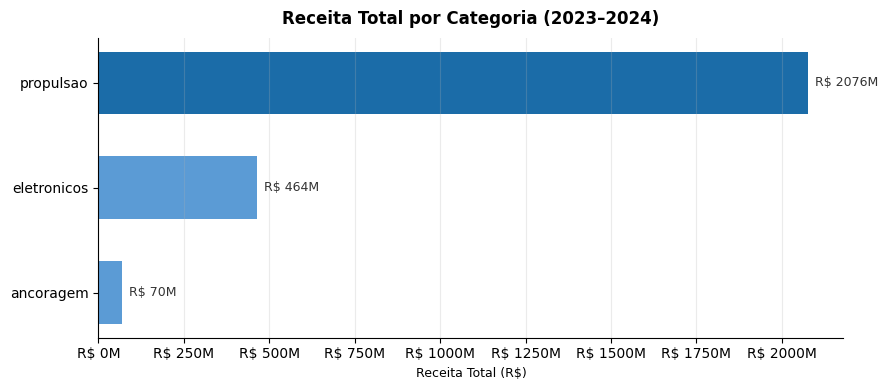

✓ g1_receita_categoria.png salvo


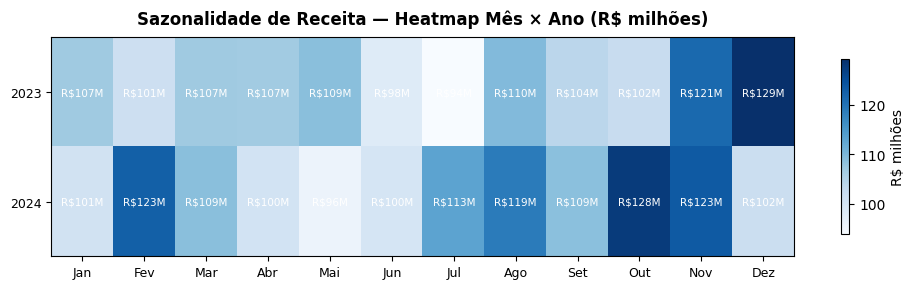

✓ g2_heatmap_sazonalidade.png salvo


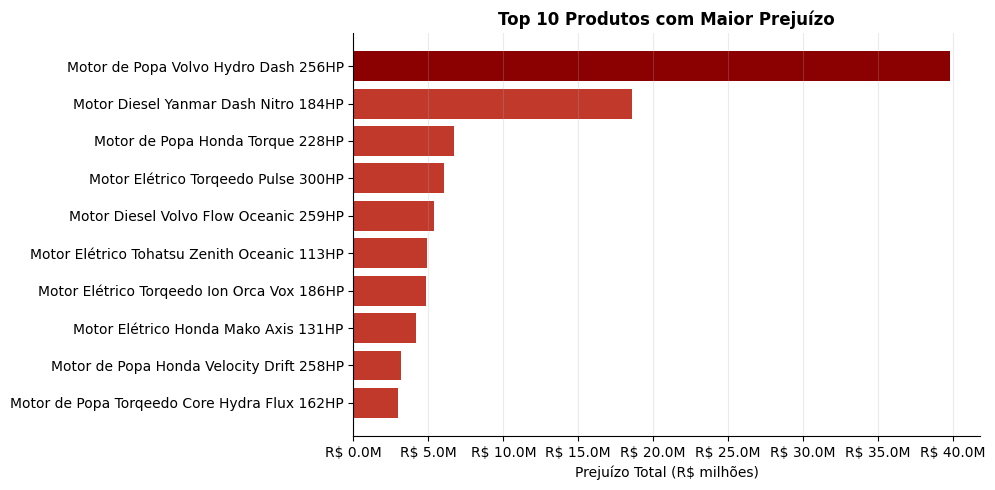

✓ top10_prejuizo_vermelho.png salvo


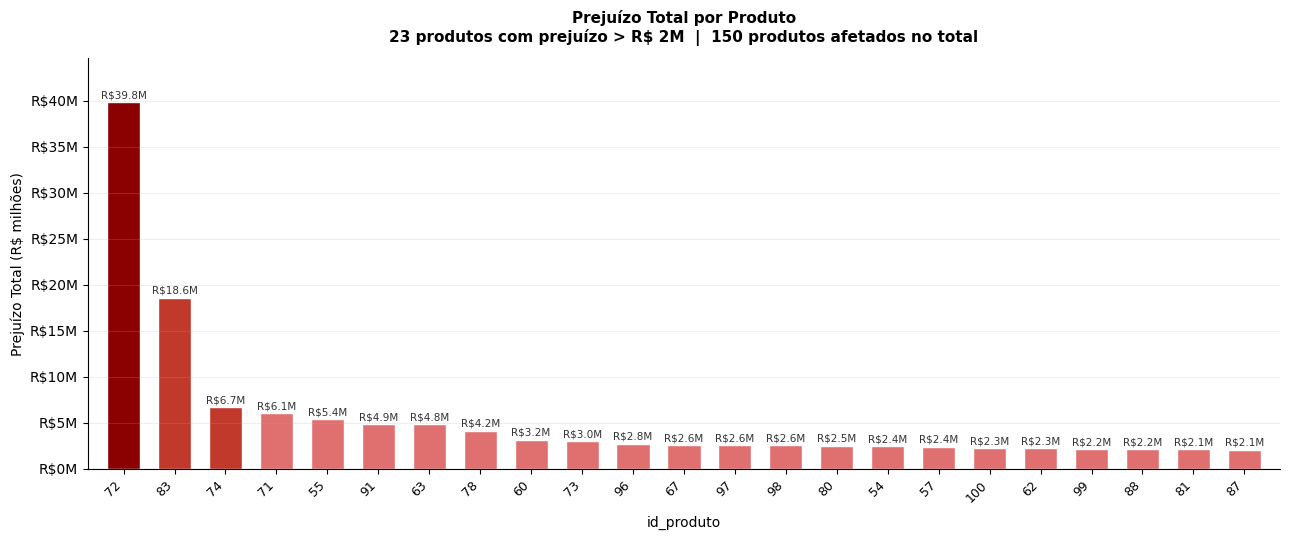

✓ prejuizo_todos_produtos.png salvo (23 produtos com prejuízo > R$5M)


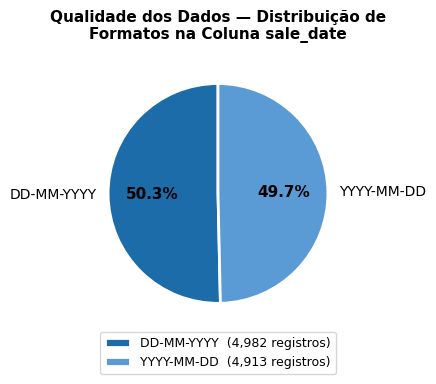

✓ g5_formatos_data.png salvo


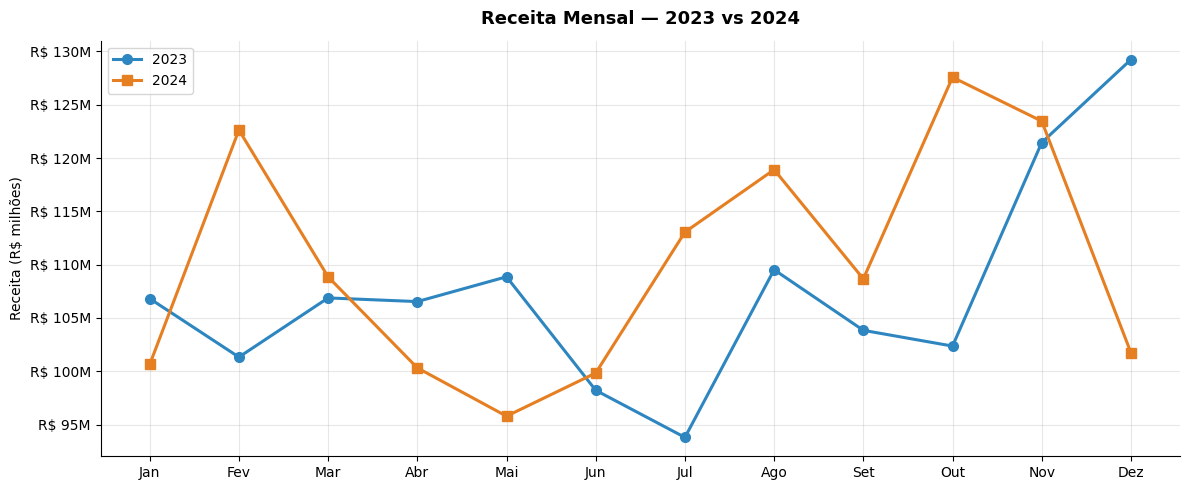

✓ receita_mensal_yoy.png salvo


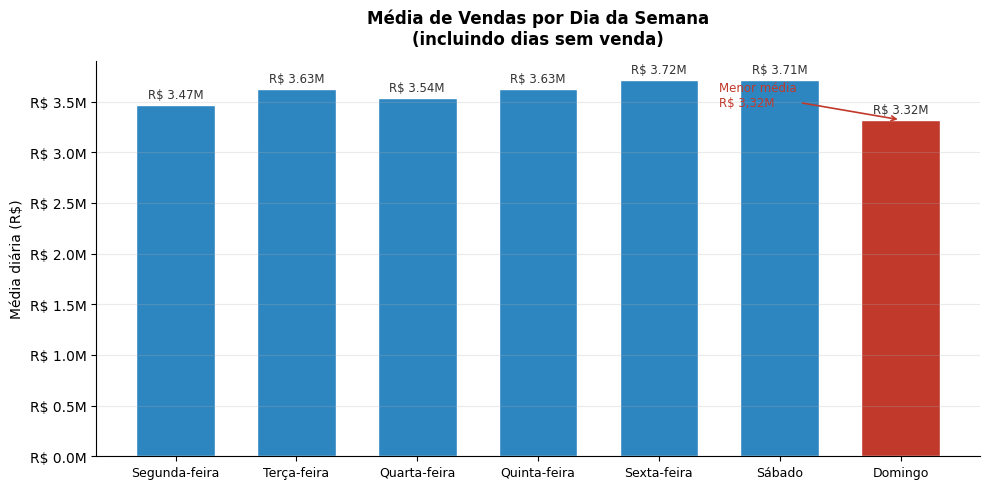

✓ q6_media_dia_semana.png salvo


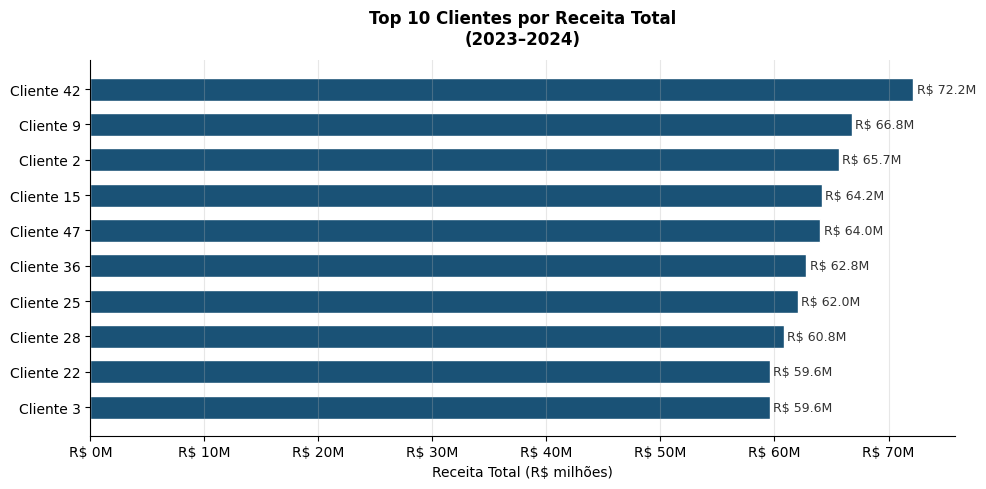

✓ q5_top_clientes.png salvo

✓ Todos os gráficos da seção 9 salvos em ../media/
  Existentes:
    media/g1_receita_categoria.png
    media/g2_heatmap_sazonalidade.png
    media/top10_prejuizo_vermelho.png
    media/prejuizo_todos_produtos.png
    media/g5_formatos_data.png
    media/receita_mensal_yoy.png
    media/q6_media_dia_semana.png
    media/q5_top_clientes.png


In [43]:
# =============================================================================
# SEÇÃO 9 — ANÁLISE EXPLORATÓRIA COMPLEMENTAR
# Gera os gráficos do material executivo e salva em ../media/
# Premissa: todas as células anteriores já foram executadas, portanto
# os seguintes objetos já estão disponíveis na memória:
#   • df_vendas                — vendas com sale_date parseado (datetime)
#   • df_produtos_normalizado  — catálogo limpo com actual_category
#   • df_custos_normalizado    — custos históricos expandidos (product_id, start_date, usd_price)
#   • df_calendario_ptax       — câmbio PTAX diário com ffill (data, cotacaoVenda)
# =============================================================================


# ─── Join base: vendas + categoria ───────────────────────────────────────────
df_base = df_vendas.merge(
    df_produtos_normalizado[['code', 'actual_category']],
    left_on='id_product', right_on='code', how='left'
)

# ─── AS-OF join seguro: custo USD vigente na data de cada venda ───────────────
# Para cada venda, buscamos o último preço USD do produto
# cuja data de vigência (start_date) seja <= data da venda.
# Usamos .apply() linha a linha — mais lento mas sem risco de broadcast.
#
# df_custos_normalizado tem colunas: product_id, start_date, usd_price
# Pré-ordenamos por product_id e start_date para o .iloc[-1] pegar o mais recente.

df_custos_sorted = df_custos_normalizado.sort_values(['product_id', 'start_date'])

def custo_vigente_na_data(row):
    """Retorna o usd_price vigente para o produto na data da venda."""
    tabela = df_custos_sorted[
        (df_custos_sorted['product_id'] == row['id_product']) &
        (df_custos_sorted['start_date'] <= row['sale_date'])
    ]
    return tabela['usd_price'].iloc[-1] if not tabela.empty else None

print("Calculando custo USD vigente por transação (pode levar alguns segundos)...")
df_base['usd_price'] = df_base.apply(custo_vigente_na_data, axis=1)
print(f"  Transações sem custo mapeado: {df_base['usd_price'].isna().sum()}")

# ─── Join com câmbio do dia da venda ─────────────────────────────────────────
df_prej = df_base.merge(
    df_calendario_ptax[['data', 'cotacaoVenda']],
    left_on=df_base['sale_date'].dt.normalize(),
    right_on='data',
    how='left'
).drop(columns='key_0', errors='ignore')

# Custo total em BRL e prejuízo por transação
df_prej['custo_total_brl'] = df_prej['usd_price'] * df_prej['cotacaoVenda'] * df_prej['qtd']
df_prej['prejuizo']        = (df_prej['custo_total_brl'] - df_prej['total']).clip(lower=0)

print(f"  Transações com prejuízo: {(df_prej['prejuizo'] > 0).sum():,} "
      f"de {len(df_prej):,} ({(df_prej['prejuizo'] > 0).mean()*100:.1f}%)")

# =============================================================================
# GRÁFICO 1 — Receita por categoria
# Responde: "onde está o dinheiro da LH Nautical?"
# Não depende de câmbio — usa apenas a coluna total (receita em BRL).
# =============================================================================

receita_cat = (
    df_base.groupby('actual_category')['total']
    .sum()
    .sort_values(ascending=True)   # ascending=True → maior fica no topo do barh
)

cores_cat = ['#1B6CA8' if v == receita_cat.max() else '#5B9BD5'
             for v in receita_cat]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(receita_cat.index, receita_cat.values, color=cores_cat, height=0.6)

for bar, val in zip(bars, receita_cat.values):
    ax.text(val + receita_cat.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'R$ {val/1e6:.0f}M', va='center', fontsize=9, color='#333')

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R$ {x/1e6:.0f}M'))
ax.set_title('Receita Total por Categoria (2023–2024)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Receita Total (R$)', fontsize=9)
ax.grid(True, axis='x', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(BASE_DIR / 'media/g1_receita_categoria.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ g1_receita_categoria.png salvo")

# =============================================================================
# GRÁFICO 2 — Heatmap de sazonalidade (mês × ano)
# Responde: "quando a empresa vende mais ao longo do ano?"
# Não depende de câmbio.
# =============================================================================

df_base['mes'] = df_base['sale_date'].dt.month
df_base['ano'] = df_base['sale_date'].dt.year

heatmap_data = (
    df_base.groupby(['ano', 'mes'])['total']
    .sum()
    .unstack(fill_value=0) / 1e6
)

meses_pt = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
            7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}
heatmap_data.columns = [meses_pt[m] for m in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(heatmap_data.values, cmap='Blues', aspect='auto')

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.values[i, j]
        cor_txt = 'white' if val > heatmap_data.values.max() * 0.6 else '#333'
        ax.text(j, i, f'R${val:.0f}M',
                ha='center', va='center', fontsize=7.5, color=cor_txt)

ax.set_xticks(range(12))
ax.set_xticklabels(heatmap_data.columns, fontsize=9)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)
ax.set_title('Sazonalidade de Receita — Heatmap Mês × Ano (R$ milhões)',
             fontsize=12, fontweight='bold', pad=10)
plt.colorbar(im, ax=ax, label='R$ milhões', shrink=0.8)
plt.tight_layout()
plt.savefig(BASE_DIR / 'media/g2_heatmap_sazonalidade.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ g2_heatmap_sazonalidade.png salvo")

# =============================================================================
# GRÁFICO 3 — Top 10 produtos com maior prejuízo (versão vermelha)
# Usa câmbio PTAX real via df_calendario_ptax.
# =============================================================================

df_prej_agg = (
    df_prej.groupby('id_product')['prejuizo']
    .sum()
    .reset_index()
    .merge(df_produtos_normalizado[['code', 'name']],
           left_on='id_product', right_on='code', how='left')
    .sort_values('prejuizo', ascending=False)
)

df_top10 = df_prej_agg.head(10).copy()
cores_prej = ['#8B0000' if i == 0 else '#C0392B' for i in range(len(df_top10))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df_top10['name'], df_top10['prejuizo'], color=cores_prej)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
ax.set_xlabel('Prejuízo Total (R$ milhões)')
ax.set_title('Top 10 Produtos com Maior Prejuízo', fontweight='bold', fontsize=12)
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(BASE_DIR / 'media/top10_prejuizo_vermelho.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ top10_prejuizo_vermelho.png salvo")

## =============================================================================
# GRÁFICO 4 — Produtos com prejuízo > R$ 2 milhões
# Corte em R$2M mantém 23 produtos — legível sem sobreposição.
# O título informa que 150 produtos foram afetados no total.
# Usa câmbio PTAX real via df_calendario_ptax.
# =============================================================================

CORTE = 2e6   # alterar aqui para mudar o limiar Atual: 2M

df_todos = df_prej_agg[df_prej_agg['prejuizo'] > CORTE].reset_index(drop=True)
n = len(df_todos)
ids = [str(int(r['id_product'])) for _, r in df_todos.iterrows()]
cores_todos = ['#8B0000' if i == 0 else '#C0392B' if i < 3 else '#E07070'
               for i in range(n)]

fig, ax = plt.subplots(figsize=(13, 5.5))
bars = ax.bar(range(n), df_todos['prejuizo'] / 1e6,
              color=cores_todos, width=0.65, edgecolor='white')

for bar, val in zip(bars, df_todos['prejuizo']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'R${val/1e6:.1f}M', ha='center', va='bottom', fontsize=7.5, color='#333')

ax.set_xticks(range(n))
ax.set_xticklabels(ids, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('id_produto', fontsize=10, labelpad=8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${x:.0f}M'))
ax.set_ylabel('Prejuízo Total (R$ milhões)', fontsize=10)
ax.set_title(
    f'Prejuízo Total por Produto\n'
    f'{n} produtos com prejuízo > R$ 2M  |  150 produtos afetados no total',
    fontsize=11, fontweight='bold', pad=12
)
ax.set_xlim(-0.7, n - 0.3)
ax.set_ylim(0, df_todos['prejuizo'].max() / 1e6 * 1.12)
ax.grid(True, axis='y', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(BASE_DIR / 'media/prejuizo_todos_produtos.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ prejuizo_todos_produtos.png salvo ({n} produtos com prejuízo > R$5M)")

# =============================================================================
# GRÁFICO 5 — Distribuição de formatos de data (pizza)
# Documenta o problema de qualidade encontrado na Q1.
# Não depende de câmbio — analisa o CSV bruto antes do parse.
# =============================================================================

df_raw_dates = pd.read_csv(path_input_vendas, usecols=['sale_date'])

def detecta_formato(d):
    if re.match(r'^\d{4}-\d{2}-\d{2}$', str(d)): return 'YYYY-MM-DD'
    if re.match(r'^\d{2}-\d{2}-\d{4}$', str(d)): return 'DD-MM-YYYY'
    return 'Outro'

contagem = df_raw_dates['sale_date'].apply(detecta_formato).value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
wedges, texts, autotexts = ax.pie(
    contagem.values,
    labels=contagem.index,
    autopct='%1.1f%%',
    colors=['#1B6CA8', '#5B9BD5', '#AED6F1'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')

ax.set_title('Qualidade dos Dados — Distribuição de\nFormatos na Coluna sale_date',
             fontsize=11, fontweight='bold', pad=12)

labels_n = [f"{k}  ({v:,} registros)" for k, v in contagem.items()]
ax.legend(wedges, labels_n, loc='lower center',
          bbox_to_anchor=(0.5, -0.18), fontsize=9)

plt.tight_layout()
plt.savefig(BASE_DIR / 'media/g5_formatos_data.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ g5_formatos_data.png salvo")

# =============================================================================
# GRÁFICO 6 — Receita mensal YoY (2023 vs 2024)
# Responde: "como evoluiu a receita mês a mês entre os dois anos?"
# Não depende de câmbio — usa apenas a coluna total (receita em BRL).
# =============================================================================
 
df_base['mes'] = df_base['sale_date'].dt.month   # já criado no G2, sem problema recriar
df_base['ano'] = df_base['sale_date'].dt.year
 
mensal = df_base.groupby(['ano', 'mes'])['total'].sum().reset_index()
 
meses_pt = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
            7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}
mensal['mes_label'] = mensal['mes'].map(meses_pt)
 
fig, ax = plt.subplots(figsize=(12, 5))
for ano, cor, marker in [(2023, '#2e86c1', 'o'), (2024, '#e67e22', 's')]:
    d = mensal[mensal['ano'] == ano].sort_values('mes')
    ax.plot(d['mes_label'], d['total'] / 1e6,
            marker=marker, linewidth=2.2, markersize=7,
            label=str(ano), color=cor)
 
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R$ {x:.0f}M'))
ax.set_title('Receita Mensal — 2023 vs 2024', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Receita (R$ milhões)', fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(BASE_DIR / 'media/receita_mensal_yoy.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ receita_mensal_yoy.png salvo")
 
# =============================================================================
# GRÁFICO 7 — Média de vendas por dia da semana (com zeros do calendário)
# Responde: "qual dia da semana tem menor média? (Q6)"
# Usa o mesmo método do SQL da Q6: reindexação com calendário completo.
# Não depende de câmbio.
# =============================================================================
 
dias_pt = {0:'Segunda-feira', 1:'Terça-feira', 2:'Quarta-feira',
           3:'Quinta-feira',  4:'Sexta-feira', 5:'Sábado', 6:'Domingo'}
ordem_dias = list(dias_pt.values())
 
# Calendário completo entre min e max data
cal = pd.DataFrame({
    'data': pd.date_range(df_vendas['sale_date'].min(),
                          df_vendas['sale_date'].max(), freq='D')
})
cal['dia_semana'] = cal['data'].dt.dayofweek.map(dias_pt)
 
# Vendas diárias (soma de total por dia)
vendas_dia = (df_vendas.groupby(df_vendas['sale_date'].dt.normalize())['total']
              .sum().reset_index())
vendas_dia.columns = ['data', 'total_dia']
 
# LEFT JOIN: dias sem venda recebem 0
base_cal = cal.merge(vendas_dia, on='data', how='left').fillna(0)
 
# Média por dia da semana na ordem correta
media_dia = (base_cal.groupby('dia_semana')['total_dia']
             .mean()
             .reindex(ordem_dias))
 
cores_dia = ['#C0392B' if d == 'Domingo' else '#2e86c1' for d in ordem_dias]
 
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(ordem_dias, media_dia.values, color=cores_dia, width=0.65, edgecolor='white')
 
# Rótulo em cima de cada barra
for bar, val in zip(bars, media_dia.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + media_dia.max() * 0.01,
            f'R$ {val/1e6:.2f}M', ha='center', va='bottom', fontsize=8.5, color='#333')
 
# Anotação do pior dia
idx_dom = ordem_dias.index('Domingo')
ax.annotate('Menor média\nR$ 3,32M',
    xy=(idx_dom, media_dia['Domingo']),
    xytext=(idx_dom - 1.5, media_dia['Domingo'] * 1.04),
    fontsize=8.5, color='#C0392B',
    arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.2))
 
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
ax.set_ylabel('Média diária (R$)', fontsize=10)
ax.set_title('Média de Vendas por Dia da Semana\n(incluindo dias sem venda)',
             fontsize=12, fontweight='bold', pad=12)
ax.tick_params(axis='x', labelsize=9)
ax.grid(True, axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(BASE_DIR / 'media/q6_media_dia_semana.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ q6_media_dia_semana.png salvo")
 
# =============================================================================
# GRÁFICO 8 — Top 10 clientes por receita total
# Responde: "quem são os maiores clientes da LH Nautical?"
# Não depende de câmbio — usa apenas a coluna total (receita em BRL).
# Nota: usa id_client como identificador pois não há nome de cliente
#       nos dados disponíveis.
# =============================================================================
 
top_clientes = (
    df_vendas.groupby('id_client')['total']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_clientes.columns = ['id_client', 'receita_total']
top_clientes['label'] = 'Cliente ' + top_clientes['id_client'].astype(str)
 
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    top_clientes['label'][::-1],        # inverter para maior ficar no topo
    top_clientes['receita_total'][::-1] / 1e6,
    color='#1a5276', edgecolor='white', height=0.65
)
 
for bar, val in zip(bars, top_clientes['receita_total'][::-1] / 1e6):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'R$ {val:.1f}M', va='center', fontsize=9, color='#333')
 
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R$ {x:.0f}M'))
ax.set_xlabel('Receita Total (R$ milhões)', fontsize=10)
ax.set_title('Top 10 Clientes por Receita Total\n(2023–2024)',
             fontsize=12, fontweight='bold', pad=12)
ax.grid(True, axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(BASE_DIR / 'media/q5_top_clientes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ q5_top_clientes.png salvo")
 
# =============================================================================
# RESUMO FINAL — todos os arquivos gerados na seção 9
# =============================================================================
print("\n✓ Todos os gráficos da seção 9 salvos em ../media/")
print("  Existentes:")
print("    media/g1_receita_categoria.png")
print("    media/g2_heatmap_sazonalidade.png")
print("    media/top10_prejuizo_vermelho.png")
print("    media/prejuizo_todos_produtos.png")
print("    media/g5_formatos_data.png")
print("    media/receita_mensal_yoy.png")
print("    media/q6_media_dia_semana.png")
print("    media/q5_top_clientes.png")

 

In [44]:
# =============================================================================
# VERIFICAÇÃO FINAL — Receita total e por categoria
# Para cards no material executivo
# =============================================================================

receita_total = df_vendas['total'].sum()
receita_por_cat = (
    df_base
    .groupby('actual_category')['total']
    .sum()
    .sort_values(ascending=False)
)

print(f"Receita TOTAL do período:  R$ {receita_total:>15,.0f}  ({receita_total/1e9:.2f} Bi)")
print()
print("Receita por categoria:")
for cat, val in receita_por_cat.items():
    pct = val / receita_total * 100
    print(f"  {cat:<15} R$ {val:>15,.0f}  ({val/1e9:.2f} Bi  |  {pct:.1f}%)")

Receita TOTAL do período:  R$   2,610,279,511  (2.61 Bi)

Receita por categoria:
  propulsao       R$   2,076,274,141  (2.08 Bi  |  79.5%)
  eletronicos     R$     464,173,618  (0.46 Bi  |  17.8%)
  ancoragem       R$      69,831,752  (0.07 Bi  |  2.7%)
